# Linear Univariate Models
Test linear and/or univariate models on single granularities.


# 0. Imports

In [1]:
# To be able to import utils' functions
import sys
from pathlib import Path

parent_dir = str(Path.cwd().parent)

if parent_dir not in sys.path:
    sys.path.append(parent_dir)

In [2]:
# Utils
from utils.data_loader_utils import load_sales_data
from utils.feature_engineering_utils import create_features

from tqdm import tqdm

import os

import logging

# Types
from typing import List, Tuple

# Data Analysis
import pandas as pd
import numpy as np

# Feature Engineering
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer

# Models
from pmdarima.arima import ARIMA, ndiffs, nsdiffs
from statsmodels.tsa.stattools import acf, pacf
from sklearn.metrics import root_mean_squared_log_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.model_selection import TimeSeriesSplit

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# 1. Load Data

In [3]:
df_sales = load_sales_data(
    sales_data_path='../data/train.csv',
    add_demand_classification=True
)

df_sales = df_sales[df_sales['date'] >= '2017-01-01'] # Filter out data before 2017 to focus on more recent trends

display(df_sales)

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type
2596374,2017-01-01,1,AUTOMOTIVE,0.000,0,53.055,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic
2596375,2017-01-01,1,BABY CARE,0.000,0,53.055,Quito,Pichincha,D,13,N/A,N/A,N/A,intermittent
2596376,2017-01-01,1,BEAUTY,0.000,0,53.055,Quito,Pichincha,D,13,N/A,N/A,N/A,smooth
2596377,2017-01-01,1,BEVERAGES,0.000,0,53.055,Quito,Pichincha,D,13,N/A,N/A,N/A,smooth
2596378,2017-01-01,1,BOOKS,0.000,0,53.055,Quito,Pichincha,D,13,N/A,N/A,N/A,intermittent
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,2017-08-15,9,POULTRY,438.133,0,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000884,2017-08-15,9,PREPARED FOODS,154.553,1,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000885,2017-08-15,9,PRODUCE,2419.729,148,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth
3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,lumpy


In [4]:
# Check demand_type distribution
df_sales['granularity_pair'] = list(zip(df_sales["store_nbr"], df_sales["family"]))

print(df_sales.groupby('demand_type')['granularity_pair'].nunique().sort_values(ascending=False))

df_sales.drop(columns=['granularity_pair'], inplace=True)

demand_type
smooth          944
erratic         374
intermittent    280
lumpy           184
Name: granularity_pair, dtype: int64


In [5]:
display(df_sales.groupby('demand_type')['sales'].sum().reset_index().sort_values('sales', ascending=False))

,demand_type,sales
3,smooth,1.625982e+08
0,erratic,3.081109e+07
1,intermittent,6.097030e+05
2,lumpy,1.980670e+05


# 2. ARIMA and Variations

In [6]:
# Select granularity with a lot of sales
df_subset = df_sales[(df_sales['store_nbr'] == 45) & (df_sales['family'] == 'GROCERY I')].sort_values(by='date')

display(df_subset)

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type
2597673,2017-01-01,45,GROCERY I,0.0,0,53.055000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2599455,2017-01-02,45,GROCERY I,22978.0,112,52.707500,Quito,Pichincha,A,11,Traslado Primer dia del ano,N/A,N/A,smooth
2601237,2017-01-03,45,GROCERY I,15997.0,105,52.360000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2603019,2017-01-04,45,GROCERY I,13312.0,135,53.260000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2604801,2017-01-05,45,GROCERY I,10805.0,67,53.770000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2993277,2017-08-11,45,GROCERY I,11088.0,40,48.810000,Quito,Pichincha,A,11,Traslado Primer Grito de Independencia,N/A,N/A,smooth
2995059,2017-08-12,45,GROCERY I,9917.0,39,48.403333,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2996841,2017-08-13,45,GROCERY I,12723.0,38,47.996667,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth
2998623,2017-08-14,45,GROCERY I,9665.0,39,47.590000,Quito,Pichincha,A,11,N/A,N/A,N/A,smooth


## 2. 1. ARIMA

In [7]:
# Helper functions to choose p and qvalues
def estimate_p_from_pacf(pacf_values: List[float], signif: float = 0.2) -> int:
    """
    Return number of significant PACF lags.

    Args:
        pacf_values(List[float]): lists with
            the series' partial autocorrelations.
        signif (float, optional): minimum
            significance for a partial autocorrelation
            to be considered. Defaults to 0.2.
    
    Returns:
        int: calculated optimal ARIMA's p value.
    """
    significant_lags = [i for i, v in enumerate(pacf_values[1:], start=1) if abs(v) > signif]

    if not significant_lags:
        return 0
    
    return min(max(significant_lags), 5)

def estimate_q_from_acf(acf_values: List[float], signif: float = 0.2) -> int:
    """
    Return number of significant ACF lags.

    Args:
        acf_values(List[float]): lists with
            the series' autocorrelations.
        signif (float, optional): minimum
            significance for a partial autocorrelation
            to be considered. Defaults to 0.2.
    
    Returns:
        int: calculated optimal ARIMA's p value.
    """
    significant_lags = [i for i, v in enumerate(acf_values[1:], start=1) if abs(v) > signif]

    if not significant_lags:
        return 0
    
    return min(max(significant_lags), 5)

In [8]:
def plot_last_fold(df_sales: pd.DataFrame, fold_data: dict,
                   date_col: str = 'date'):
    """
    Plot results from the last fold of a cross-validation.
    
    Args:
        df_sales: Original dataframe with dates
        fold_data: Dictionary with last fold data
        date_col: name of the date_column. Defaults
            to 'date'.
    """
    
    train_idx = fold_data['train_idx']
    test_idx = fold_data['test_idx']
    
    # Get last 90 days of training for visualization
    train_plot_start = max(0, len(train_idx) - 90)
    train_plot_indices = train_idx[train_plot_start:]
    
    # Extract data
    dates_train = df_sales[date_col].iloc[train_plot_indices].values
    y_train = fold_data['y_train'].iloc[train_plot_start:].values \
        if isinstance(fold_data['y_train'], pd.Series) else fold_data['y_train']
    fitted = fold_data['fitted_values'].iloc[train_plot_start:].values \
        if isinstance(fold_data['fitted_values'], pd.Series) else fold_data['fitted_values']
    
    dates_test = df_sales[date_col].iloc[test_idx].values 
    y_test = fold_data['y_test'].values if isinstance(fold_data['y_test'], pd.Series) else fold_data['y_test']
    forecast = fold_data['forecast'].values if isinstance(fold_data['forecast'], pd.Series) else fold_data['forecast']
    
    # Create plot
    plt.figure(figsize=(14, 6))
    
    # Train data
    sns.lineplot(
        x=dates_train,
        y=y_train,
        label='Train (Real)',
        alpha=0.7,
        color='blue'
    )
    
    # Fitted values
    
    sns.lineplot(
        x=dates_train,
        y=fitted,
        label='Fitted Values',
        linestyle='--',
        color='blue',
        alpha=0.5
    )
    
    # Test data
    sns.lineplot(
        x=dates_test,
        y=y_test,
        label='Test (Real)',
        alpha=0.7,
        color='green',
        linewidth=2
    )
    
    # Forecast
    sns.lineplot(
        x=dates_test,
        y=forecast,
        label='Forecast',
        linestyle='--',
        color='red',
        linewidth=2
    )
        
    plt.title("Real vs Predicted (Last Fold)")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Running 5 folds with test_size=15...

Estimated ARIMA order: (5, 0, 5)



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\

Fold 1:
  Train: 2017-01-01 to 2017-06-01
  Test:  2017-06-02 to 2017-06-16
  Train RMSLE: 0.8203
  Test RMSLE: 0.1349



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Fold 2:
  Train: 2017-01-01 to 2017-06-16
  Test:  2017-06-17 to 2017-07-01
  Train RMSLE: 0.7855
  Test RMSLE: 0.1508



...

Fold 3:
  Train: 2017-01-01 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.7527
  Test RMSLE: 0.1634



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Fold 4:
  Train: 2017-01-01 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.7246
  Test RMSLE: 0.0907



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Fold 5:
  Train: 2017-01-01 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.6987
  Test RMSLE: 0.1915

Cross-Validation Results:
   Train RMSLE Mean: 0.7564
   Train RMSLE Std:  0.0431
   Train Min RMSLE:  0.6987
   Train Max RMSLE:  0.8203
   Test RMSLE Mean: 0.1463
   Test RMSLE Std:  0.0334
   Test Min RMSLE:  0.0907
   Test Max RMSLE:  0.1915


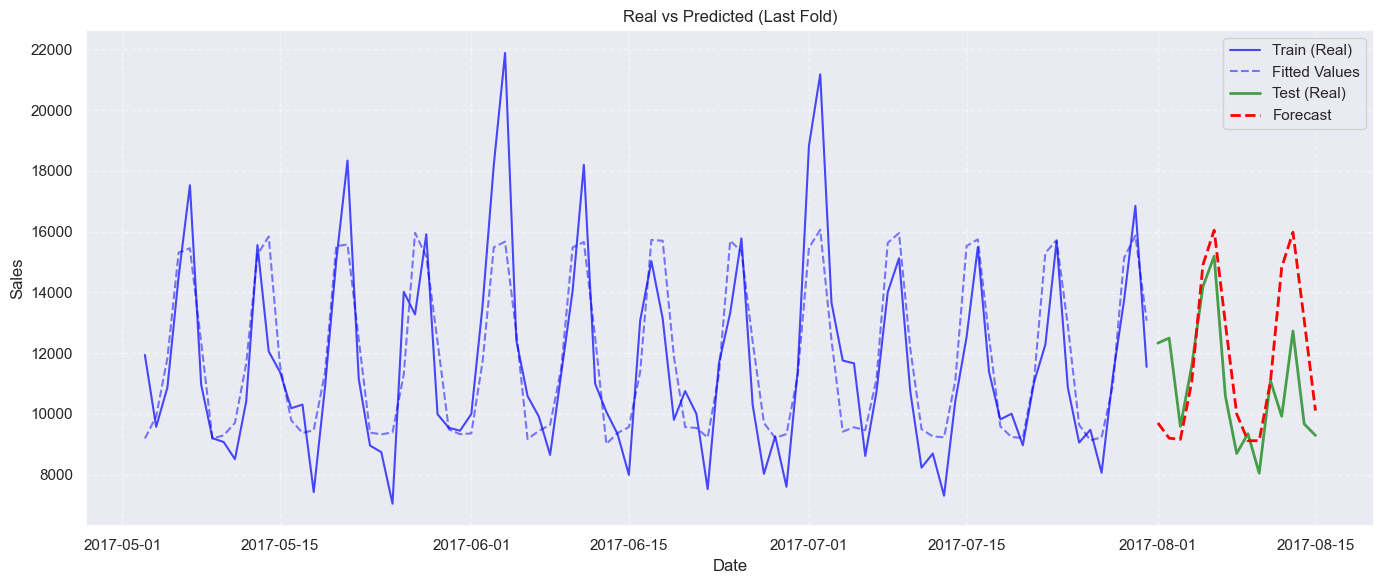

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,arima_order,total_sales,sales_count,demand_type,n_folds
0,45,GROCERY I,0.756353,0.043079,0.698697,0.820251,0.146251,0.033388,0.090721,0.191502,"(5, 0, 5)",2685639.0,226,smooth,5


In [9]:
def train_and_evaluate_arima_model(
    df_sales: pd.DataFrame,
    n_splits: int = 5,
    test_size: int = 15,
    plot_results: bool = False,
    skew_threshold: float = None,
    verbose: bool = False
) -> pd.DataFrame:
    """
    Train and evaluate an ARIMA model using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe with 'date' and 'sales'.
        n_splits (int): Number of cross-validation splits.
        test_size (int): Size of test set in each fold.
        plot_results (bool): Whether to plot results from last fold.
        skew_threshold (float): If not None and skewness exceeds this value,
            log transformation is applied.
        verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    df_sales = df_sales.copy()
    df_sales = df_sales.set_index('date').sort_index()
    
    target_column = 'sales'
    non_zero_sales_count = len(df_sales[df_sales['sales'] > 0])

    store_nbr = df_sales['store_nbr'].iloc[0]
    family = df_sales['family'].iloc[0]
    demand_type = df_sales['demand_type'].iloc[0]

    if len(df_sales) > 0:
        # Apply log transformation if needed
        if skew_threshold and abs(df_sales['sales'].skew()) > skew_threshold:
            df_sales['sales_log'] = np.log1p(df_sales['sales'])
            target_column = 'sales_log'

        y = df_sales[target_column]

        # Time Series Cross-Validation
        tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
        
        train_cv_metrics = []
        test_cv_metrics = []
        last_fold_data = None

        if verbose:
            print(f"Running {tscv.get_n_splits(y)} folds with test_size={test_size}...\n")

        for fold, (train_idx, test_idx) in enumerate(tscv.split(y), 1):
            # Split data
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            try:
                # Estimate ARIMA parameters
                d = ndiffs(y_train)
                
                y_train_diff = y_train.copy()
                
                for _ in range(d):
                    y_train_diff = y_train_diff.diff().fillna(0)

                acf_vals = acf(y_train_diff, nlags=30)
                pacf_vals = pacf(y_train_diff, nlags=30)

                p = estimate_p_from_pacf(pacf_vals)
                q = estimate_q_from_acf(acf_vals)

                if verbose and fold == 1:
                    print(f"Estimated ARIMA order: ({p}, {d}, {q})\n")

                # Train ARIMA model
                arima = ARIMA(
                    order=(p, d, q)
                )
                
                fitted_arima = arima.fit(y_train)

                # Predict test period
                test_forecast = fitted_arima.predict(n_periods=len(y_test))
                test_forecast = np.array(test_forecast)

                fitted_values = fitted_arima.predict_in_sample()

                # Remove negative values, if any
                test_forecast = [forecast if forecast >= 0 else 0 for forecast in test_forecast]
                fitted_values = [val if val >= 0 else 0 for val in fitted_values]

                # Calculate metrics
                if 'log' in target_column:
                    fitted_values_real = np.expm1(fitted_values)
                    y_train_real = np.expm1(y_train)

                    y_test_real = np.expm1(y_test)
                    forecast_real = np.expm1(test_forecast)
                else:
                    fitted_values_real = fitted_values
                    y_train_real = y_train

                    y_test_real = y_test
                    forecast_real = test_forecast

                train_rmsle = root_mean_squared_log_error(y_train_real, fitted_values_real)
                test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

                train_cv_metrics.append(train_rmsle)
                test_cv_metrics.append(test_rmsle)

                if verbose:
                    train_dates = df_sales.iloc[train_idx].index
                    test_dates = df_sales.iloc[test_idx].index
                    print(f"Fold {fold}:")
                    print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
                    print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

                    print(f"  Train RMSLE: {train_rmsle:.4f}")
                    print(f"  Test RMSLE: {test_rmsle:.4f}\n")

                # Store last fold data for plotting
                if fold == tscv.get_n_splits(y):
                    fitted_values = fitted_arima.predict_in_sample()
                    
                    if 'log' in target_column:
                        fitted_values_real = np.expm1(fitted_values)
                        y_train_real = np.expm1(y_train)
                    else:
                        fitted_values_real = fitted_values
                        y_train_real = y_train
                        
                    last_fold_data = {
                        'train_idx': train_idx,
                        'test_idx': test_idx,
                        'y_train': y_train_real,
                        'fitted_values': fitted_values_real,
                        'y_test': y_test_real,
                        'forecast': forecast_real,
                        'order': (p, d, q)
                    }

            except Exception as e:
                if verbose:
                    print(f"Error in Fold {fold}: {str(e)}\n")
                continue

        # Print summary
        if len(test_cv_metrics) > 0:
            df_sales = df_sales.reset_index()  # Ensure 'date' is a column for plotting
            
            mean_train_rmsle = np.mean(train_cv_metrics)
            std_train_rmsle = np.std(train_cv_metrics)

            mean_test_rmsle = np.mean(test_cv_metrics)
            std_test_rmsle = np.std(test_cv_metrics)
            
            if verbose:
                print("=" * 60)
                print("Cross-Validation Results:")
                print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
                print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
                print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
                print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
                print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
                print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
                print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
                print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
                print("=" * 60)

            # Plot last fold if requested
            if plot_results and last_fold_data is not None:
                plot_last_fold(df_sales, last_fold_data)

            return pd.DataFrame({
                'store_nbr': store_nbr,
                'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
                'train_rmsle_mean': [mean_train_rmsle],
                'train_rmsle_std': [std_train_rmsle],
                'train_rmsle_min': [min(train_cv_metrics)],
                'train_rmsle_max': [max(train_cv_metrics)],
                'test_rmsle_mean': [mean_test_rmsle],
                'test_rmsle_std': [std_test_rmsle],
                'test_rmsle_min': [min(test_cv_metrics)],
                'test_rmsle_max': [max(test_cv_metrics)],
                'arima_order': [str(last_fold_data['order']) if last_fold_data else None],
                'total_sales': [df_sales['sales'].sum()],
                'sales_count': [non_zero_sales_count],
                'demand_type': demand_type,
                'n_folds': [len(test_cv_metrics)]
            })
        else:
            if verbose:
                print("No successful folds completed")
            
            return pd.DataFrame({
                'store_nbr': store_nbr,
                'family': family,
                'train_rmsle_mean': [np.nan],
                'train_rmsle_std': [np.nan],
                'train_rmsle_min': [np.nan],
                'train_rmsle_max': [np.nan],
                'test_rmsle_mean': [np.nan],
                'test_rmsle_std': [np.nan],
                'test_rmsle_min': [np.nan],
                'test_rmsle_max': [np.nan],
                'arima_order': [None],
                'total_sales': [df_sales['sales'].sum()],
                'sales_count': [non_zero_sales_count],
                'demand_type': demand_type,
                'n_folds': [0]
            })
    else:
        return pd.DataFrame({
            'store_nbr': store_nbr,
            'family': family,
            'train_rmsle_mean': [0],
            'train_rmsle_std': [0],
            'train_rmsle_min': [0],
            'train_rmsle_max': [0],
            'test_rmsle_mean': [0],
            'test_rmsle_std': [0],
            'test_rmsle_min': [0],
            'test_rmsle_max': [0],
            'arima_order': [0],
            'total_sales': [0],
            'sales_count': [0],
            'demand_type': [demand_type],
            'n_folds': [0]
        })


df_metrics = train_and_evaluate_arima_model(df_subset, verbose=True, plot_results=True)

display(df_metrics)

In [10]:
df_sampled = pd.read_csv('../data/experiments_results/sampled_data.csv').fillna('N/A')

display(df_sampled)

,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type
0,2017-04-15,1,AUTOMOTIVE,3.000,0,52.905,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic
1,2017-04-15,10,MAGAZINES,0.000,0,52.905,Quito,Pichincha,C,15,N/A,N/A,N/A,intermittent
2,2017-04-15,10,SCHOOL AND OFFICE SUPPLIES,0.000,0,52.905,Quito,Pichincha,C,15,N/A,N/A,N/A,lumpy
3,2017-04-15,11,GROCERY II,26.000,0,52.905,Cayambe,Pichincha,B,6,N/A,N/A,N/A,erratic
4,2017-04-15,11,HOME CARE,653.000,18,52.905,Cayambe,Pichincha,B,6,N/A,N/A,N/A,smooth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10942,2017-08-15,7,PET SUPPLIES,5.000,0,47.570,Quito,Pichincha,D,8,N/A,N/A,N/A,smooth
10943,2017-08-15,8,CELEBRATION,13.000,0,47.570,Quito,Pichincha,D,8,N/A,N/A,N/A,smooth
10944,2017-08-15,8,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.570,Quito,Pichincha,D,8,N/A,N/A,N/A,lumpy
10945,2017-08-15,9,HOME CARE,373.000,6,47.570,Quito,Pichincha,B,6,N/A,N/A,N/A,smooth


In [11]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training ARIMA model'):
    try:
        df_metrics = train_and_evaluate_arima_model(df)

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_arima = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_arima.sort_values(by='test_rmsle_mean'))

Training ARIMA model:   0%|          | 0/89 [00:00<?, ?it/s]c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will b

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,arima_order,total_sales,sales_count,demand_type,n_folds
32,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)",0.000000,0,intermittent,4
20,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)",0.000000,0,intermittent,4
54,35,LAWN AND GARDEN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)",0.000000,0,lumpy,4
61,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)",0.000000,0,intermittent,4
83,51,PRODUCE,0.126332,0.005453,0.120335,0.133875,0.112641,0.024804,0.070242,0.131628,"(5, 0, 5)",710326.193900,123,erratic,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47,31,LAWN AND GARDEN,0.901605,0.019623,0.884654,0.934514,0.845154,0.193823,0.677072,1.172534,"(1, 0, 1)",507.000000,98,lumpy,4
26,17,LINGERIE,0.811883,0.021781,0.776960,0.830325,0.885686,0.162706,0.610977,1.035708,"(5, 1, 5)",725.000000,116,erratic,4
36,25,FROZEN FOODS,1.446991,0.114061,1.310110,1.625671,1.299696,0.802434,0.781156,2.685051,"(5, 1, 5)",16155.850006,123,erratic,4
85,52,SCHOOL AND OFFICE SUPPLIES,0.993381,0.033263,0.965109,1.049930,1.591913,0.172777,1.332052,1.758988,"(5, 1, 5)",2232.000000,113,erratic,4


In [12]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_arima.to_csv('../data/experiments_results/arima.csv')

# df_full_metrics_arima = pd.read_csv('../data/experiments_results/arima.csv')

## 2. 2. SARIMA

In [13]:
def infer_seasonal_orders(
    y: pd.Series,
    seasonal_period: int,
    max_P: int = 2,
    max_Q: int = 2,
) -> Tuple[int, int]:
    """
    Infer seasonal SARIMA orders (P, Q) using seasonal ACF and PACF peaks.

    Args:
        y (pd.Series): Time series.
        seasonal_period (int): Seasonal period m.
        max_P (int): Maximum seasonal AR order to consider.
        max_Q (int): Maximum seasonal MA order to consider.

    Returns:
        Tuple[int, int]: (P, Q)
    """
    y_clean = y.dropna()

    acf_vals = acf(y_clean, nlags=seasonal_period * 3, fft=True)
    pacf_vals = pacf(y_clean, nlags=seasonal_period * 3)
    conf = 1.96 / np.sqrt(len(y_clean))

    P = 0
    for k in range(1, max_P + 1):
        lag = k * seasonal_period
        if lag < len(pacf_vals) and abs(pacf_vals[lag]) > conf:
            P = k
            break

    Q = 0
    for k in range(1, max_Q + 1):
        lag = k * seasonal_period
        if lag < len(acf_vals) and abs(acf_vals[lag]) > conf:
            Q = k
            break

    return P, Q

c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


Running 5 folds with test_size=15...

Estimated SARIMA order: (5, 0, 5) x (1, 0, 1, 7)



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided.

Fold 1:
  Train: 2017-01-01 to 2017-06-01
  Test:  2017-06-02 to 2017-06-16
  Train RMSLE: 0.8223
  Test RMSLE: 0.1668



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_mod

...

Fold 3:
  Train: 2017-01-01 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.7572
  Test RMSLE: 0.1631



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided.

Fold 4:
  Train: 2017-01-01 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.7265
  Test RMSLE: 0.0758



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Fold 5:
  Train: 2017-01-01 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.7018
  Test RMSLE: 0.1500

Cross-Validation Results:
   Train RMSLE Mean: 0.7520
   Train RMSLE Std:  0.0451
   Train Min RMSLE:  0.7018
   Train Max RMSLE:  0.8223
   Test RMSLE Mean: 0.1389
   Test RMSLE Std:  0.0370
   Test Min RMSLE:  0.0758
   Test Max RMSLE:  0.1668


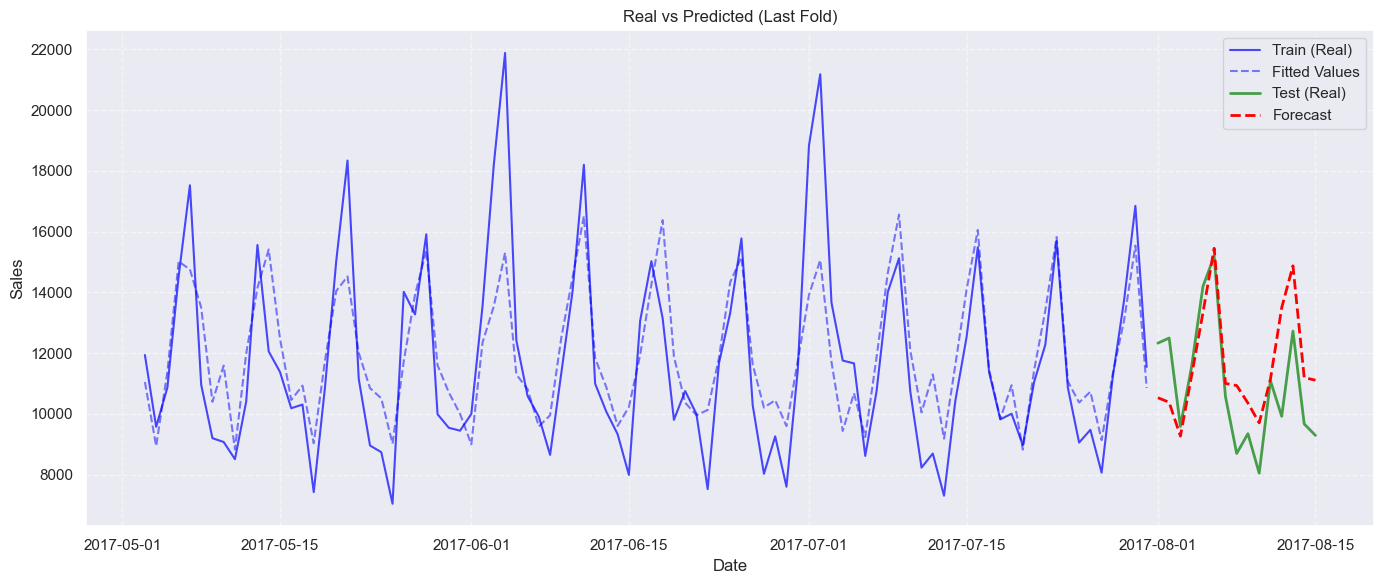

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,sarima_order,sarima_seasonal,total_sales,sales_count,demand_type,n_folds
0,45,GROCERY I,0.751963,0.045113,0.701846,0.822326,0.138907,0.036982,0.075768,0.166762,"(5, 0, 5)","(1, 0, 1, 7)",2685639.0,226,smooth,4


In [14]:
def train_and_evaluate_sarima_model(
    df_sales: pd.DataFrame,
    n_splits: int = 5,
    test_size: int = 15,
    plot_results: bool = False,
    skew_threshold: float = None,
    verbose: bool = False
) -> pd.DataFrame:
    """
    Train and evaluate a SARIMA model using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe with 'date' and 'sales'.
        n_splits (int): Number of cross-validation splits.
        test_size (int): Size of test set in each fold.
        plot_results (bool): Whether to plot results from last fold.
        skew_threshold (float): If not None and skewness exceeds this value,
            log transformation is applied.
        verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    df_sales = df_sales.sort_values(by='date').copy()
    target_column = 'sales'
    non_zero_sales_count = len(df_sales[df_sales['sales'] > 0])

    # Apply log transformation if needed
    if skew_threshold and df_sales['sales'].skew() > skew_threshold:
        df_sales['sales_log'] = np.log1p(df_sales['sales'])
        target_column = 'sales_log'

    y = df_sales[target_column]

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    test_cv_metrics = []
    train_cv_metrics = []
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(y)} folds with test_size={test_size}...\n")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(y), 1):
        # Split data
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        try:
            # Estimate non-seasonal parameters
            d = ndiffs(y_train)
            
            y_train_diff = y_train.copy()
            for _ in range(d):
                y_train_diff = y_train_diff.diff()
            
            y_train_diff = y_train_diff.dropna()

            acf_vals = acf(y_train_diff, nlags=min(30, len(y_train_diff)//2))
            pacf_vals = pacf(y_train_diff, nlags=min(30, len(y_train_diff)//2))

            p = estimate_p_from_pacf(pacf_vals)
            q = estimate_q_from_acf(acf_vals)

            # Estimate seasonal parameters
            D = nsdiffs(y_train, m=7)
            
            y_train_seasonal_diff = y_train.copy()
            for _ in range(D):
                y_train_seasonal_diff = y_train_seasonal_diff.diff(7)
            
            y_train_seasonal_diff = y_train_seasonal_diff.dropna()
            
            P, Q = infer_seasonal_orders(y=y_train_seasonal_diff, seasonal_period=7, max_P=5, max_Q=5)

            if verbose and fold == 1:
                print(f"Estimated SARIMA order: ({p}, {d}, {q}) x ({P}, {D}, {Q}, 7)\n")

            # Train SARIMA model
            arima = ARIMA(
                order=(p, d, q),
                seasonal_order=(P, D, Q, 7)
            )
            
            fitted_arima = arima.fit(y_train)

            # Predict test period
            test_forecast = fitted_arima.predict(n_periods=len(y_test))
            test_forecast = np.array(test_forecast)

            fitted_values = fitted_arima.fittedvalues()

            # Remove negative values, if any
            test_forecast = [forecast if forecast >= 0 else 0 for forecast in test_forecast]
            fitted_values = [val if val >= 0 else 0 for val in fitted_values]

            # Calculate metrics
            if 'log' in target_column:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train)

                y_test_real = np.expm1(y_test)
                forecast_real = np.expm1(test_forecast)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train

                y_test_real = y_test
                forecast_real = test_forecast

            train_rmsle = root_mean_squared_log_error(y_train_real, fitted_values_real)
            test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

            train_cv_metrics.append(train_rmsle)
            test_cv_metrics.append(test_rmsle)

            if verbose:
                train_dates = df_sales['date'].iloc[train_idx]
                test_dates = df_sales['date'].iloc[test_idx]
                print(f"Fold {fold}:")
                print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
                print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

                print(f"  Train RMSLE: {train_rmsle:.4f}")
                print(f"  Test RMSLE: {test_rmsle:.4f}\n")

            # Store last fold data for plotting
            if fold == tscv.get_n_splits(y):
                fitted_values = fitted_arima.fittedvalues()
                
                if 'log' in target_column:
                    fitted_values_real = np.expm1(fitted_values)
                    y_train_real = np.expm1(y_train)
                else:
                    fitted_values_real = fitted_values
                    y_train_real = y_train
                    
                last_fold_data = {
                    'train_idx': train_idx,
                    'test_idx': test_idx,
                    'y_train': y_train_real,
                    'fitted_values': fitted_values_real,
                    'y_test': y_test_real,
                    'forecast': forecast_real,
                    'order': (p, d, q),
                    'seasonal_order': (P, D, Q, 7)
                }

        except Exception as e:
            if verbose:
                print(f"Error in Fold {fold}: {str(e)}\n")
            continue

    # Print summary
    if len(test_cv_metrics) > 0:
        df_sales = df_sales.reset_index()  # Ensure 'date' is a column for plotting
        
        mean_train_rmsle = np.mean(train_cv_metrics)
        std_train_rmsle = np.std(train_cv_metrics)

        mean_test_rmsle = np.mean(test_cv_metrics)
        std_test_rmsle = np.std(test_cv_metrics)
        
        if verbose:
            print("=" * 60)
            print("Cross-Validation Results:")
            print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
            print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
            print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
            print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
            print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
            print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
            print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
            print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
            print("=" * 60)

        # Plot last fold if requested
        if plot_results and last_fold_data is not None:
            plot_last_fold(df_sales, last_fold_data)

        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [mean_train_rmsle],
            'train_rmsle_std': [std_train_rmsle],
            'train_rmsle_min': [min(train_cv_metrics)],
            'train_rmsle_max': [max(train_cv_metrics)],
            'test_rmsle_mean': [mean_test_rmsle],
            'test_rmsle_std': [std_test_rmsle],
            'test_rmsle_min': [min(test_cv_metrics)],
            'test_rmsle_max': [max(test_cv_metrics)],
            'sarima_order': [str(last_fold_data['order']) if last_fold_data else None],
            'sarima_seasonal': [str(last_fold_data['seasonal_order']) if last_fold_data else None],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [len(test_cv_metrics)]
        })
    else:
        if verbose:
            print("No successful folds completed")
        
        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [np.nan],
            'train_rmsle_std': [np.nan],
            'train_rmsle_min': [np.nan],
            'train_rmsle_max': [np.nan],
            'test_rmsle_mean': [np.nan],
            'test_rmsle_std': [np.nan],
            'test_rmsle_min': [np.nan],
            'test_rmsle_max': [np.nan],
            'sarima_order': [None],
            'sarima_seasonal': [None],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [0]
        })



df_metrics = train_and_evaluate_sarima_model(df_subset, verbose=True, plot_results=True)

display(df_metrics)

In [15]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training SARIMA model'):
    try:
        df_metrics = train_and_evaluate_sarima_model(df)

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_sarima = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_sarima.sort_values(by='test_rmsle_mean'))

Training SARIMA model:   0%|          | 0/89 [00:00<?, ?it/s]c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Program

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,sarima_order,sarima_seasonal,total_sales,sales_count,demand_type,n_folds
32,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)","(0, 0, 0, 7)",0.000000,0,intermittent,5
54,35,LAWN AND GARDEN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)","(0, 0, 0, 7)",0.000000,0,lumpy,5
61,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)","(0, 0, 0, 7)",0.000000,0,intermittent,5
20,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)","(0, 0, 0, 7)",0.000000,0,intermittent,5
66,41,BABY CARE,0.057653,0.057808,0.000000,0.121280,0.119749,0.094350,0.000000,0.253102,"(5, 0, 2)","(2, 0, 0, 7)",6.000000,6,intermittent,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47,31,LAWN AND GARDEN,0.917113,0.035639,0.884654,0.979148,0.853920,0.174245,0.677072,1.172534,"(1, 0, 1)","(0, 0, 0, 7)",507.000000,98,lumpy,5
26,17,LINGERIE,0.779589,0.066523,0.650119,0.830175,0.994399,0.210811,0.610977,1.201775,"(5, 1, 5)","(2, 0, 0, 7)",725.000000,116,erratic,5
85,52,SCHOOL AND OFFICE SUPPLIES,1.141326,0.114615,1.018113,1.322445,1.496113,0.147012,1.332052,1.733166,"(5, 1, 5)","(1, 0, 1, 7)",2232.000000,113,erratic,5
36,25,FROZEN FOODS,1.382735,0.162003,1.250622,1.667599,1.606442,0.717992,0.678619,2.608593,"(5, 1, 5)","(1, 0, 1, 7)",16155.850006,123,erratic,5


In [16]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_sarima.to_csv('../data/experiments_results/sarima.csv')

# df_full_metrics_sarima = pd.read_csv('../data/experiments_results/sarima.csv')

## 2. 3. SARIMAX

In [17]:
# df_sales, feature_names = create_features(df_sales)
df_sampled, feature_names = create_features(df_sampled)

feature_names = feature_names[:3]

print(feature_names)
display(df_sampled)

['onpromotion', 'month', 'dcoilwtico']


,date,store_nbr,family,sales,onpromotion,dcoilwtico,store_city,store_state,store_type,store_cluster,event_description_national,event_description_regional,event_description_local,demand_type,month
0,2017-04-15,1,AUTOMOTIVE,3.000,0,52.905000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,4
1,2017-04-16,1,AUTOMOTIVE,1.000,0,52.762500,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,4
2,2017-04-17,1,AUTOMOTIVE,1.000,0,52.620000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,4
3,2017-04-18,1,AUTOMOTIVE,3.000,0,52.460000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,4
4,2017-04-19,1,AUTOMOTIVE,4.000,0,50.490000,Quito,Pichincha,D,13,N/A,N/A,N/A,erratic,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10942,2017-08-11,54,PRODUCE,546.250,3,48.810000,El Carmen,Manabi,C,3,Traslado Primer Grito de Independencia,N/A,N/A,smooth,8
10943,2017-08-12,54,PRODUCE,696.920,4,48.403333,El Carmen,Manabi,C,3,N/A,N/A,N/A,smooth,8
10944,2017-08-13,54,PRODUCE,877.304,4,47.996667,El Carmen,Manabi,C,3,N/A,N/A,N/A,smooth,8
10945,2017-08-14,54,PRODUCE,585.615,3,47.590000,El Carmen,Manabi,C,3,N/A,N/A,N/A,smooth,8


Running 5 folds with test_size=15...

Estimated SARIMAX order: (5, 0, 5) x (1, 0, 1, 7)



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\bas

Available features: ['dcoilwtico', 'scaler__onpromotion']
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  152
Model:             SARIMAX(5, 0, 5)x(1, 0, [1], 7)   Log Likelihood               -1252.018
Date:                             Sun, 10 May 2026   AIC                           2536.036
Time:                                     03:37:14   BIC                           2582.988
Sample:                                          0   HQIC                          2555.116
                                             - 152                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    -14.5127     58.043     -0.250     

c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided.

Available features: ['dcoilwtico', 'scaler__onpromotion']
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  167
Model:             SARIMAX(5, 0, 5)x(1, 0, [1], 7)   Log Likelihood               -1383.455
Date:                             Sun, 10 May 2026   AIC                           2798.909
Time:                                     03:37:15   BIC                           2847.500
Sample:                                          0   HQIC                          2818.647
                                             - 167                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      4.0719     21.903      0.186     

...

Available features: ['dcoilwtico', 'scaler__onpromotion']
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  182
Model:             SARIMAX(5, 0, 5)x(1, 0, [1], 7)   Log Likelihood               -1512.990
Date:                             Sun, 10 May 2026   AIC                           3057.981
Time:                                     03:37:17   BIC                           3108.059
Sample:                                          0   HQIC                          3078.304
                                             - 182                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      5.0763     12.864      0.395     

c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided.

Available features: ['dcoilwtico', 'scaler__onpromotion']
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  197
Model:             SARIMAX(5, 0, 5)x(1, 0, [1], 7)   Log Likelihood               -1644.978
Date:                             Sun, 10 May 2026   AIC                           3321.957
Time:                                     03:37:18   BIC                           3373.396
Sample:                                          0   HQIC                          3342.805
                                             - 197                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.5243      6.776     -0.225     

c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Available features: ['dcoilwtico', 'scaler__onpromotion']
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  212
Model:             SARIMAX(5, 0, 5)x(1, 0, [1], 7)   Log Likelihood               -1773.215
Date:                             Sun, 10 May 2026   AIC                           3578.429
Time:                                     03:37:19   BIC                           3631.122
Sample:                                          0   HQIC                          3599.756
                                             - 212                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      2.4703      7.481      0.330     

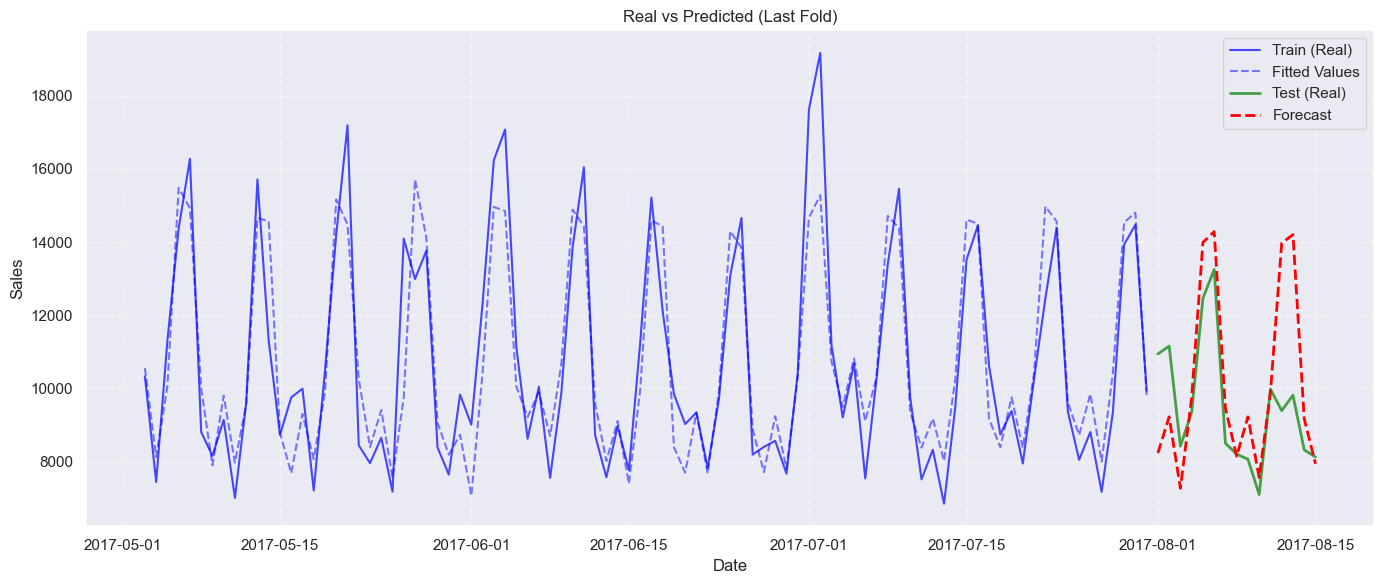

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,sarima_order,sarima_seasonal,total_sales,sales_count,demand_type,n_folds
0,44,GROCERY I,1.040191,0.056235,0.949615,1.121267,0.129798,0.03072,0.097765,0.182205,"(5, 0, 5)","(1, 0, 1, 7)",2464555.0,226,smooth,5


In [18]:
def train_and_evaluate_sarimax_model(
    df_sales: pd.DataFrame,
    feature_names: List[str],
    n_splits: int = 5,
    test_size: int = 15,
    plot_results: bool = False,
    skew_threshold: float = None,
    verbose: bool = False
) -> pd.DataFrame:
    """
    Train and evaluate a SARIMAX model using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe with 'date', 'sales' and exogenous features.
        feature_names (List[str]): List of exogenous feature names to use.
        n_splits (int): Number of cross-validation splits.
        test_size (int): Size of test set in each fold.
        plot_results (bool): Whether to plot results from last fold.
        skew_threshold (float): If not None and skewness exceeds this value,
            log transformation is applied.
        verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    
    df_sales = df_sales.sort_values(by='date').copy()
    target_column = 'sales'
    non_zero_sales_count = len(df_sales[df_sales['sales'] > 0])

    # Apply log transformation if needed
    if skew_threshold and df_sales['sales'].skew() > skew_threshold:
        df_sales['sales_log'] = np.log1p(df_sales['sales'])
        target_column = 'sales_log'

    # Prepare data
    X = df_sales.drop(labels=[target_column], axis=1)
    y = df_sales[target_column]

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)
    
    train_cv_metrics = []
    test_cv_metrics = []
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(y)} folds with test_size={test_size}...\n")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(y), 1):
        # Split data
        X_train = X.iloc[train_idx].copy()
        X_test = X.iloc[test_idx].copy()
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        try:
            # Estimate non-seasonal parameters
            d = ndiffs(y_train, test='adf')
            
            y_train_diff = y_train.copy()
            for _ in range(d):
                y_train_diff = y_train_diff.diff()
            
            y_train_diff = y_train_diff.dropna()

            acf_vals = acf(y_train_diff, nlags=min(30, len(y_train_diff)//2))
            pacf_vals = pacf(y_train_diff, nlags=min(30, len(y_train_diff)//2))

            p = estimate_p_from_pacf(pacf_vals)
            q = estimate_q_from_acf(acf_vals)

            # Estimate seasonal parameters
            D = nsdiffs(y_train, m=7)
            
            y_train_seasonal_diff = y_train.copy()
            for _ in range(D):
                y_train_seasonal_diff = y_train_seasonal_diff.diff(7)
            
            y_train_seasonal_diff = y_train_seasonal_diff.dropna()
            
            P, Q = infer_seasonal_orders(y=y_train_seasonal_diff, seasonal_period=7)

            if verbose and fold == 1:
                print(f"Estimated SARIMAX order: ({p}, {d}, {q}) x ({P}, {D}, {Q}, 7)\n")

            # Prepare exogenous features
            # categorical_features = ['event_description_national', 'event_description_regional', 'event_description_local', 'month']
            all_feature_names = feature_names.copy()

            # Frequency encoding for categorical features
            # for categorical_feature in categorical_features:
            #     if categorical_feature in X_train.columns:
            #         freq_map = X_train[categorical_feature].value_counts()
            #         X_train[categorical_feature] = X_train[categorical_feature].map(freq_map).fillna(0)
            #         X_test[categorical_feature] = X_test[categorical_feature].map(freq_map).fillna(0)

            # Scale numerical features
            numerical_features = ['onpromotion']

            for numerical_feature in numerical_features:
                all_feature_names.remove(numerical_feature)

                all_feature_names.append(f"scaler__{numerical_feature}")

            ct = ColumnTransformer(
                [("scaler", StandardScaler(), numerical_features)],
                remainder='passthrough'
            )

            X_train_transformed = ct.fit_transform(X_train)
            X_test_transformed = ct.transform(X_test)

            X_train_processed = pd.DataFrame(
                X_train_transformed,
                columns=ct.get_feature_names_out(),
                index=X_train.index
            )

            X_test_processed = pd.DataFrame(
                X_test_transformed,
                columns=ct.get_feature_names_out(),
                index=X_test.index
            )

            X_train_processed.columns = X_train_processed.columns.str.replace(r'^remainder__', '', regex=True)
            X_test_processed.columns = X_test_processed.columns.str.replace(r'^remainder__', '', regex=True)

            # Remove constant columns
            encoded_features = [f"scaler__{numerical_feature}" for numerical_feature in numerical_features] #+ categorical_features
            constant_cols = [col for col in encoded_features if col in X_train_processed.columns and X_train_processed[col].nunique() <= 1]

            for col in constant_cols:
                if col in all_feature_names:
                    all_feature_names.remove(col)
                X_train_processed.drop(columns=col, inplace=True, errors='ignore')
                X_test_processed.drop(columns=col, inplace=True, errors='ignore')

            # Train SARIMAX model
            arima = ARIMA(
                order=(p, d, q),
                seasonal_order=(P, D, Q, 7),
                enforce_stationarity=False
            )
            
            # Filter features that exist in processed data
            available_features = [f for f in all_feature_names if f in X_train_processed.columns]

            if len(available_features) > 0:
                fitted_arima = arima.fit(y_train, X=X_train_processed[available_features].to_numpy())
                test_forecast = fitted_arima.predict(n_periods=len(y_test), X=X_test_processed[available_features].to_numpy())
            else:
                # Fallback to SARIMA without exogenous variables
                fitted_arima = arima.fit(y_train)
                test_forecast = fitted_arima.predict(n_periods=len(y_test))

            if verbose:
                print(f"Available features: {available_features}")
                print(fitted_arima.summary())
            
            test_forecast = np.array(test_forecast)

            fitted_values = fitted_arima.fittedvalues()

            # Remove negative values, if any
            test_forecast = [forecast if forecast >= 0 else 0 for forecast in test_forecast]
            fitted_values = [val if val >= 0 else 0 for val in fitted_values]

             # Calculate metrics
            if 'log' in target_column:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train)

                y_test_real = np.expm1(y_test)
                forecast_real = np.expm1(test_forecast)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train

                y_test_real = y_test
                forecast_real = test_forecast

            train_rmsle = root_mean_squared_log_error(y_train_real, fitted_values_real)
            test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

            train_cv_metrics.append(train_rmsle)
            test_cv_metrics.append(test_rmsle)

            if verbose:
                train_dates = df_sales['date'].iloc[train_idx]
                test_dates = df_sales['date'].iloc[test_idx]
                print(f"Fold {fold}:")
                print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
                print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

                print(f"  Train RMSLE: {train_rmsle:.4f}")
                print(f"  Test RMSLE: {test_rmsle:.4f}\n")

            # Store last fold data for plotting
            if fold == tscv.get_n_splits(y):
                fitted_values = fitted_arima.fittedvalues()
                
                if 'log' in target_column:
                    fitted_values_real = np.expm1(fitted_values)
                    y_train_real = np.expm1(y_train)
                else:
                    fitted_values_real = fitted_values
                    y_train_real = y_train
                    
                last_fold_data = {
                    'train_idx': train_idx,
                    'test_idx': test_idx,
                    'y_train': y_train_real,
                    'fitted_values': fitted_values_real,
                    'y_test': y_test_real,
                    'forecast': forecast_real,
                    'order': (p, d, q),
                    'seasonal_order': (P, D, Q, 7),
                    'n_features': len(available_features)
                }

        except Exception as e:
            if verbose:
                print(f"Error in Fold {fold}: {str(e)}\n")
            continue

    # Print summary
    if len(test_cv_metrics) > 0:
        mean_train_rmsle = np.mean(train_cv_metrics)
        std_train_rmsle = np.std(train_cv_metrics)

        mean_test_rmsle = np.mean(test_cv_metrics)
        std_test_rmsle = np.std(test_cv_metrics)
        
        if verbose:
            print("=" * 60)
            print("Cross-Validation Results:")
            print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
            print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
            print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
            print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
            print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
            print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
            print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
            print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
            print("=" * 60)

        # Plot last fold if requested
        if plot_results and last_fold_data is not None:
            plot_last_fold(df_sales, last_fold_data)

        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [mean_train_rmsle],
            'train_rmsle_std': [std_train_rmsle],
            'train_rmsle_min': [min(train_cv_metrics)],
            'train_rmsle_max': [max(train_cv_metrics)],
            'test_rmsle_mean': [mean_test_rmsle],
            'test_rmsle_std': [std_test_rmsle],
            'test_rmsle_min': [min(test_cv_metrics)],
            'test_rmsle_max': [max(test_cv_metrics)],
             'sarima_order': [str(last_fold_data['order']) if last_fold_data else None],
            'sarima_seasonal': [str(last_fold_data['seasonal_order']) if last_fold_data else None],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [len(test_cv_metrics)]
        })
    else:
        if verbose:
            print("No successful folds completed")
        
        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [np.nan],
            'train_rmsle_std': [np.nan],
            'train_rmsle_min': [np.nan],
            'train_rmsle_max': [np.nan],
            'test_rmsle_mean': [np.nan],
            'test_rmsle_std': [np.nan],
            'test_rmsle_min': [np.nan],
            'test_rmsle_max': [np.nan],
            'sarima_order': [None],
            'sarima_seasonal': [None],
            'total_sales': [df_sales['sales'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [0]
        })

df_subset = df_sales[(df_sales['store_nbr'] == 44) & (df_sales['family'] == 'GROCERY I')].sort_values(by='date')

df_metrics = train_and_evaluate_sarimax_model(df_subset, feature_names=[feature for feature in feature_names if feature != 'dcolwtico'], verbose=True, plot_results=True)

display(df_metrics)

In [19]:
# Run for all granularities
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Training SARIMAX model'):
    try:
        df_metrics = train_and_evaluate_sarimax_model(df, feature_names=[feature for feature in feature_names if feature != 'dcolwtico'])

        df_list.append(df_metrics)
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_sarimax = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_sarimax.sort_values(by='test_rmsle_mean'))

Training SARIMAX model:   0%|          | 0/89 [00:00<?, ?it/s]c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible 

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,sarima_order,sarima_seasonal,total_sales,sales_count,demand_type,n_folds
54,35,LAWN AND GARDEN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)","(0, 0, 0, 7)",0.000000,0,lumpy,5
32,21,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)","(0, 0, 0, 7)",0.000000,0,intermittent,5
20,14,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)","(0, 0, 0, 7)",0.000000,0,intermittent,5
61,39,BOOKS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,"(0, 0, 0)","(0, 0, 0, 7)",0.000000,0,intermittent,5
88,54,PRODUCE,0.628184,0.782383,0.160113,1.983142,0.136693,0.030809,0.107626,0.183900,"(5, 0, 5)","(1, 0, 1, 7)",83807.255030,123,smooth,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47,31,LAWN AND GARDEN,0.912460,0.064150,0.850212,1.033971,0.935329,0.321204,0.594344,1.477937,"(1, 0, 1)","(0, 0, 0, 7)",507.000000,98,lumpy,5
78,47,SCHOOL AND OFFICE SUPPLIES,0.803424,0.284928,0.635899,1.371941,1.298088,0.359254,0.942044,1.766640,"(0, 2, 0)","(0, 0, 0, 7)",9169.000000,116,lumpy,5
44,28,"LIQUOR,WINE,BEER",1.320317,0.313674,0.883730,1.636883,1.445806,0.832017,0.590166,2.635074,"(5, 0, 5)","(1, 0, 1, 7)",8080.000000,123,erratic,5
85,52,SCHOOL AND OFFICE SUPPLIES,1.249185,0.067566,1.137812,1.337704,1.484682,0.232324,1.211016,1.758988,"(5, 0, 5)","(1, 0, 1, 7)",2232.000000,113,erratic,5


In [20]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_sarimax.to_csv('../data/experiments_results/sarimax.csv')

# df_full_metrics_sarimax = pd.read_csv('./data/experiments_results/sarimax.csv')

# 3. Exponential Smoothing (Holt-Winters)

c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_mod

Running 5 folds...

Fold 0:
  Train: 2017-01-01 to 2017-06-01
  Test:  2017-06-02 to 2017-06-16
  Train RMSLE: 0.8154
  Test RMSLE: 0.1156



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_mod

Fold 1:
  Train: 2017-01-01 to 2017-06-16
  Test:  2017-06-17 to 2017-07-01
  Train RMSLE: 0.7785
  Test RMSLE: 0.0989

Fold 2:
  Train: 2017-01-01 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.7463
  Test RMSLE: 0.1160



c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_mod

Fold 3:
  Train: 2017-01-01 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.7181
  Test RMSLE: 0.0832

Fold 4:
  Train: 2017-01-01 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.6925
  Test RMSLE: 0.1930

Cross-Validation Results:
   Train RMSLE Mean: 0.7502
   Train RMSLE Std:  0.0434
   Train Min RMSLE:  0.6925
   Train Max RMSLE:  0.8154
   Test RMSLE Mean: 0.1214
   Test RMSLE Std:  0.0378
   Test Min RMSLE:  0.0832
   Test Max RMSLE:  0.1930


c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


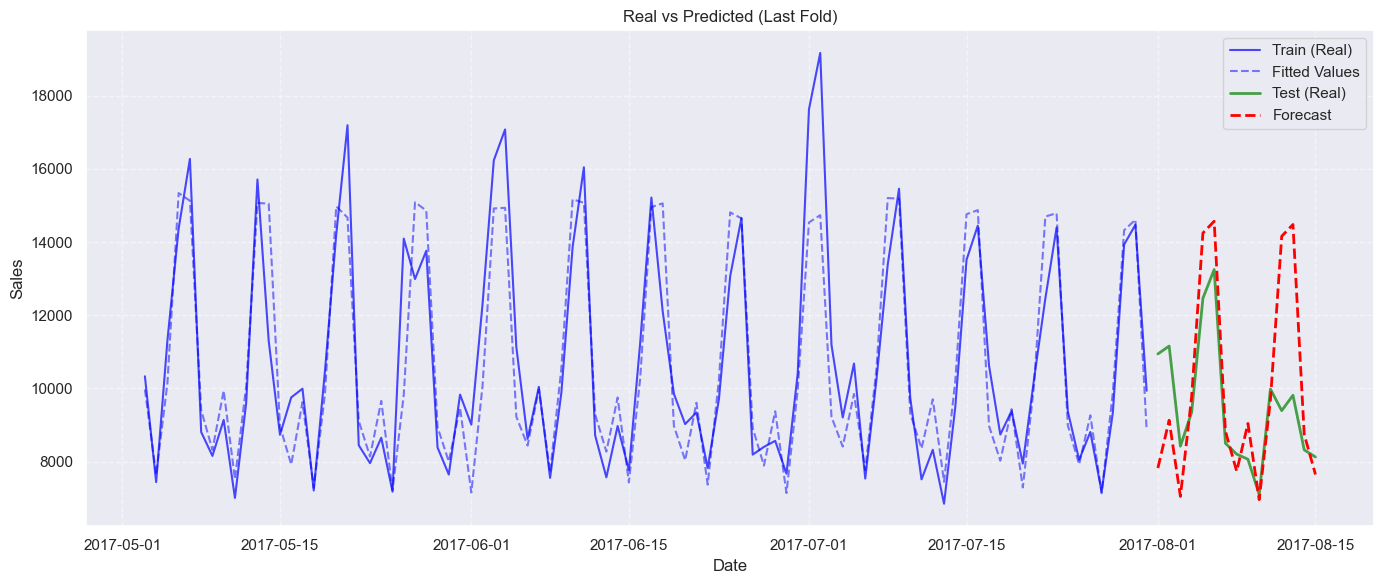

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,44,GROCERY I,0.750177,0.043448,0.692486,0.815447,0.121358,0.037835,0.083203,0.193029,2464555.0,226,smooth,5


In [21]:
def train_and_evaluate_holtwinters(
    df_sales: pd.DataFrame,
    trend: str | None = "add",
    seasonal: str | None = "add",
    seasonal_periods: int = 7,
    n_folds: int = 5,
    test_size: int = 15,
    skew_threshold: float | None = None,
    plot_results: bool = False,
    verbose: bool = False
) -> pd.DataFrame:
    """
    Train and evaluate a Holt-Winters (Exponential Smoothing) model
    for a given sales time series using Time Series Cross-Validation.

    Args:
        df_sales (pd.DataFrame): Input dataframe containing 'date' and 'sales'.
        trend (str | None): Trend component ('add', 'mul', or None).
        seasonal (str | None): Seasonal component ('add', 'mul', or None).
        seasonal_periods (int): Seasonal period of the series.
        n_folds (int, optional): amount of CV's n folds. Defaults to 5.
        test_size (int, optional): test set's size. Defaults to 15.
        skew_threshold (float | None): If not None and skewness exceeds this value,
            log transformation is applied to the target.
        plot_results (bool): Whether to plot real vs predicted values (last fold).
        verbose (bool): Whether to print model summary and performance.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    
    df_sales = df_sales.sort_values("date").copy()
    target_col = "sales"

    # Apply log transformation if needed
    if skew_threshold is not None and abs(df_sales["sales"].skew()) > skew_threshold:
        df_sales["sales_log"] = np.log1p(df_sales["sales"])
        target_col = "sales_log"

    y = df_sales[target_col]

    test_cv_metrics = []
    train_cv_metrics = []
    tscv = TimeSeriesSplit(n_splits=n_folds, test_size=test_size)

    # Variables to store last fold for plotting
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(y)} folds...\n")

    for i, (train_index, test_index) in enumerate(tscv.split(y)):
        # Train model
        model = ExponentialSmoothing(
            y.iloc[train_index],
            trend=trend,
            seasonal=seasonal,
            seasonal_periods=seasonal_periods,
            initialization_method="estimated"
        )

        fitted = model.fit()

        # Predict
        y_test_fold = y.iloc[test_index]
        y_train_fold = y.iloc[train_index]
        
        forecast = fitted.forecast(len(y_test_fold))

        fitted_values = fitted.fittedvalues.values.tolist()

        # Remove negative values, if any
        test_forecast = [forecast if forecast >= 0 else 0 for forecast in forecast]
        fitted_values = [val if val >= 0 else 0 for val in fitted_values]

        # Calculate metrics
        if 'log' in target_col:
            fitted_values_real = np.expm1(fitted_values)
            y_train_real = np.expm1(y_train_fold)

            y_test_real = np.expm1(y_test_fold)
            forecast_real = np.expm1(test_forecast)
        else:
            fitted_values_real = fitted_values
            y_train_real = y_train_fold

            y_test_real = y_test_fold
            forecast_real = test_forecast

        train_rmsle = root_mean_squared_log_error(y_train_real, fitted_values_real)
        test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

        train_cv_metrics.append(train_rmsle)
        test_cv_metrics.append(test_rmsle)

        if verbose:
            train_dates = df_sales['date'].iloc[train_index]
            test_dates = df_sales['date'].iloc[test_index]
            print(f"Fold {i}:")
            print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
            print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

            print(f"  Train RMSLE: {train_rmsle:.4f}")
            print(f"  Test RMSLE: {test_rmsle:.4f}\n")
        # Store last fold data for plotting
        if i + 1 == tscv.get_n_splits(y):
            fitted_values = fitted.fittedvalues.values.tolist()
            
            if 'log' in target_col:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(y_train_fold)
            else:
                fitted_values_real = fitted_values
                y_train_real = y_train_fold
                
            last_fold_data = {
                'train_idx': train_index,
                'test_idx': test_index,
                'y_train': y_train_real,
                'fitted_values': fitted_values_real[-90:],
                'y_test': y_test_real,
                'forecast': forecast_real,
                'seasonal': seasonal,
                'seasonal_periods': seasonal_periods
            }

    mean_train_rmsle = np.mean(train_cv_metrics)
    std_train_rmsle = np.std(train_cv_metrics)

    mean_test_rmsle = np.mean(test_cv_metrics)
    std_test_rmsle = np.std(test_cv_metrics)

    if verbose:
        print("=" * 60)
        print("Cross-Validation Results:")
        print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
        print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
        print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
        print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
        print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
        print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
        print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
        print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
        print("=" * 60)

    # Plot last fold if requested
    if plot_results and last_fold_data:
        plot_last_fold(df_sales, last_fold_data)

    return pd.DataFrame({
        'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
        'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
        'train_rmsle_mean': [mean_train_rmsle],
        'train_rmsle_std': [std_train_rmsle],
        'train_rmsle_min': [min(train_cv_metrics)],
        'train_rmsle_max': [max(train_cv_metrics)],
        'test_rmsle_mean': [mean_test_rmsle],
        'test_rmsle_std': [std_test_rmsle],
        'test_rmsle_min': [min(test_cv_metrics)],
        'test_rmsle_max': [max(test_cv_metrics)],
        'total_sales': [df_sales['sales'].sum()],
        'sales_count': [len(y[y > 0])],
        'demand_type': [df_sales['demand_type'].iloc[0]],
        'n_folds': [len(test_cv_metrics)]
    })

df_metrics = train_and_evaluate_holtwinters(
    df_subset, 
    seasonal_periods=7, 
    verbose=True, 
    plot_results=True
)
display(df_metrics)

In [22]:
df_list = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Running Holt-Winters'):
    try:
        df_list.append(train_and_evaluate_holtwinters(df))
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_holt_winters = pd.concat(df_list, ignore_index=True)

display(df_full_metrics_holt_winters)

Running Holt-Winters:   1%|          | 1/89 [00:00<00:44,  1.99it/s]c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
c:\Users\JoaoSierra\AppData\Local\Prog

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,1,AUTOMOTIVE,0.516736,0.027858,0.462705,0.537253,0.598483,0.038967,0.543095,0.649052,516.00000,119,erratic,5
1,2,GROCERY II,0.303416,0.006178,0.297038,0.312721,0.474835,0.264420,0.232497,0.988366,4900.00000,123,smooth,5
2,2,HOME AND KITCHEN I,0.634904,0.059892,0.561366,0.739510,0.667162,0.234843,0.312725,0.915896,2546.00000,123,erratic,5
3,3,BREAD/BAKERY,0.106570,0.005139,0.099984,0.115080,0.097767,0.008631,0.086096,0.106813,160765.24310,123,smooth,5
4,3,HARDWARE,0.527228,0.015210,0.501651,0.544239,0.600506,0.101842,0.410150,0.689755,424.00000,116,smooth,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,52,CELEBRATION,0.627450,0.017317,0.600520,0.647768,0.555900,0.081621,0.440716,0.654025,1343.00000,117,smooth,5
85,52,SCHOOL AND OFFICE SUPPLIES,1.185431,0.055834,1.094112,1.232855,1.277681,0.279495,0.915514,1.624858,2232.00000,113,erratic,5
86,53,FROZEN FOODS,0.209911,0.002643,0.206911,0.214144,0.232604,0.036874,0.194115,0.300542,18175.84501,123,erratic,5
87,54,HARDWARE,0.436904,0.016506,0.416394,0.455829,0.499881,0.084661,0.374825,0.635814,84.00000,56,intermittent,5


In [23]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_holt_winters.to_csv('../data/experiments_results/holt_winters.csv')

# df_full_metrics_holt_winters = pd.read_csv('../data/experiments_results/holt_winters.csv')

# 4. Prophet

Running 5 folds with test_size=15...

Fold 1:
  Train: 2017-01-01 to 2017-06-01
  Test:  2017-06-02 to 2017-06-16
  Train RMSLE: 0.7881
  Test RMSLE: 0.1089

Fold 2:
  Train: 2017-01-01 to 2017-06-16
  Test:  2017-06-17 to 2017-07-01
  Train RMSLE: 0.7535
  Test RMSLE: 0.0949

Fold 3:
  Train: 2017-01-01 to 2017-07-01
  Test:  2017-07-02 to 2017-07-16
  Train RMSLE: 0.7218
  Test RMSLE: 0.1063

Fold 4:
  Train: 2017-01-01 to 2017-07-16
  Test:  2017-07-17 to 2017-07-31
  Train RMSLE: 0.6950
  Test RMSLE: 0.0847

Fold 5:
  Train: 2017-01-01 to 2017-07-31
  Test:  2017-08-01 to 2017-08-15
  Train RMSLE: 0.6709
  Test RMSLE: 0.1831

Cross-Validation Results:
   Train RMSLE Mean: 0.7258
   Train RMSLE Std:  0.0416
   Train Min RMSLE:  0.6709
   Train Max RMSLE:  0.7881
   Test RMSLE Mean: 0.1156
   Test RMSLE Std:  0.0348
   Test Min RMSLE:  0.0847
   Test Max RMSLE:  0.1831


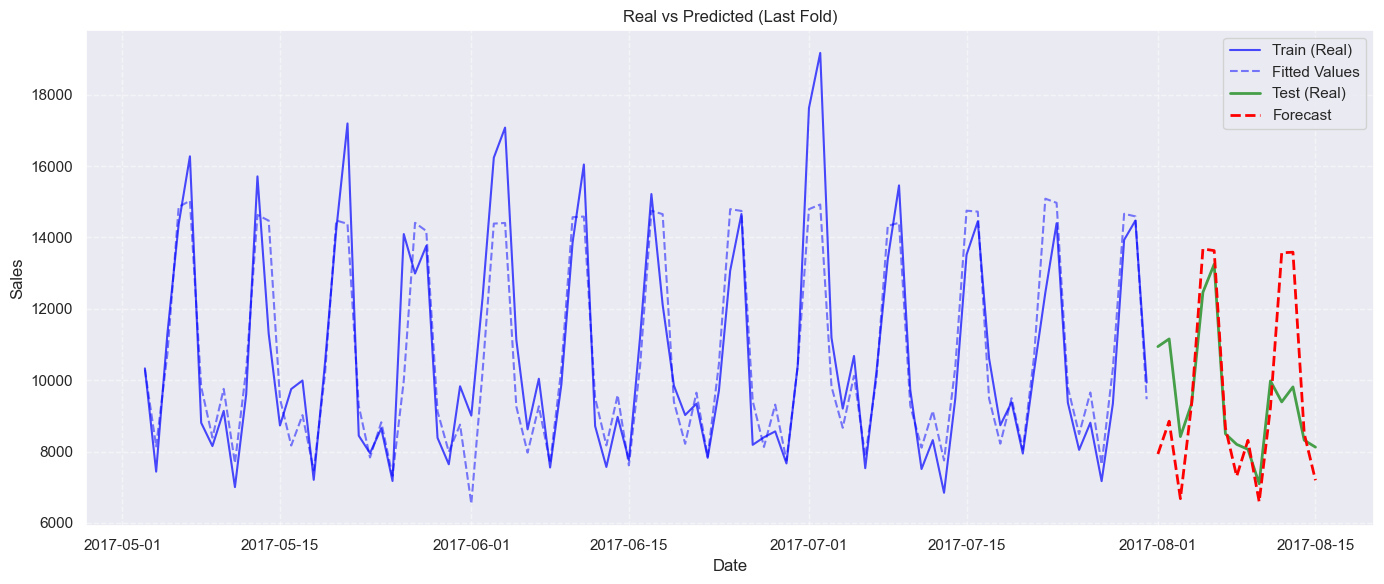

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,44,GROCERY I,0.725846,0.041553,0.670881,0.7881,0.115569,0.034846,0.084697,0.183093,2464555.0,226,smooth,5


In [24]:
from prophet import Prophet
from prophet.diagnostics import cross_validation

logging.getLogger("cmdstanpy").disabled = True #  turn 'cmdstanpy' logs off

def train_and_evaluate_prophet_model(df_sales: pd.DataFrame, feature_cols: List[str] = None,
                                     n_splits: int = 5, test_size: int = 15,
                                     skew_threshold: float = None, verbose: bool = False,
                                     plot_results: bool = False) -> pd.DataFrame:
    """
    Train and evaluate a Prophet model
    for a given granularity.

    Args:
        df_sales (pd.DataFrame): input sales data.
        feature_cols (List[str], optional): names of the
            external regressor features. Defaults to None.
        n_splits (int): Number of cross-validation splits.
        test_size (int, optional): amount of days
            in the test set.
        skew_threshold (int, optional): absolute value
            that, if the target variable's skew is
            greater, the log transformation is applied
            for. Defaults to 15.
            plot_results (bool): Whether to plot results from last fold.
            skew_threshold (float): If not None and skewness exceeds this value,
                log transformation is applied.
            verbose (bool): Whether to print detailed information.

    Returns:
        pd.DataFrame: Metrics including mean and std of RMSLE across folds.
    """
    df_sales = df_sales.sort_values(by='date')

    df_sales = df_sales.rename(columns={'date': 'ds', 'sales': 'y'})

    non_zero_sales_count = len(df_sales[df_sales['y'] > 0])

    log_transformed = False

    # Apply log transformation if needed
    if skew_threshold and df_sales['y'].skew() > skew_threshold:
        df_sales['y'] = np.log1p(df_sales['y'])

        log_transformed = True

    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

    train_cv_metrics = []
    test_cv_metrics = []
    last_fold_data = None

    if verbose:
        print(f"Running {tscv.get_n_splits(df_sales['y'])} folds with test_size={test_size}...\n")

    for fold, (train_idx, test_idx) in enumerate(tscv.split(df_sales['y']), 1):
        try:
            # Split data
            df_train = df_sales.iloc[train_idx].copy()
            df_test = df_sales.iloc[test_idx].copy()

            # Get holidays' dates
            # df_holidays = df_train[(df_train['event_description_national'] != 'N/A') | (df_train['event_description_regional'] != 'N/A') | (df_train['event_description_local'] != 'N/A')].copy()

            # df_holidays['holiday'] = df_holidays['event_description_national'].combine_first(df_holidays['event_description_regional']).combine_first(df_holidays['event_description_local'])

            # df_holidays = df_holidays[['holiday', 'ds']].drop_duplicates()

            m = Prophet(scaling='minmax')

            if feature_cols:
                for feature in feature_cols:
                    m.add_regressor(feature)

            m.fit(df_train)

            future = m.make_future_dataframe(periods=test_size, freq='D')

            if feature_cols:
                full_idx = np.concatenate([train_idx, test_idx])

                for feature in feature_cols:
                    feature_values = df_sales.iloc[full_idx][feature].values

                    future[feature] = feature_values

            df_forecast = m.predict(future)

            df_forecast_train = df_forecast.iloc[train_idx]
            df_forecast_test = df_forecast.iloc[test_idx]

            fitted_values = df_forecast_train['yhat']
            test_forecast = df_forecast_test['yhat']

            # Calculate metrics
            if log_transformed:
                fitted_values_real = np.expm1(fitted_values)
                y_train_real = np.expm1(df_train['y'])

                y_test_real = np.expm1(df_test['y'])
                forecast_real = np.expm1(test_forecast)
            else:
                fitted_values_real = fitted_values
                y_train_real = df_train['y']

                y_test_real = df_test['y']
                forecast_real = test_forecast

            # Remove negative values, if any
            fitted_values_real = [max(fitted_value, 0) for fitted_value in fitted_values_real]
            forecast_real = [max(forecast_value, 0) for forecast_value in forecast_real]

            train_rmsle = root_mean_squared_log_error(y_train_real, fitted_values_real)
            test_rmsle = root_mean_squared_log_error(y_test_real, forecast_real)

            train_cv_metrics.append(train_rmsle)
            test_cv_metrics.append(test_rmsle)

            if verbose:
                train_dates = df_sales['ds'].iloc[train_idx]
                test_dates = df_sales['ds'].iloc[test_idx]
                print(f"Fold {fold}:")
                print(f"  Train: {train_dates.min().date()} to {train_dates.max().date()}")
                print(f"  Test:  {test_dates.min().date()} to {test_dates.max().date()}")

                print(f"  Train RMSLE: {train_rmsle:.4f}")
                print(f"  Test RMSLE: {test_rmsle:.4f}\n")

            # Store last fold data for plotting
            if fold == tscv.get_n_splits(df_sales['y']):
                fitted_values = df_forecast_train['yhat']

                # Calculate metrics
                if log_transformed:
                    fitted_values_real = np.expm1(fitted_values)
                    y_train_real = np.expm1(df_train['y'])

                    y_test_real = np.expm1(df_test['y'])
                    forecast_real = np.expm1(test_forecast)
                else:
                    fitted_values_real = fitted_values
                    y_train_real = df_train['y']

                    y_test_real = df_test['y']
                    forecast_real = test_forecast
                    
                last_fold_data = {
                    'train_idx': train_idx,
                    'test_idx': test_idx,
                    'y_train': y_train_real,
                    'fitted_values': fitted_values_real,
                    'y_test': y_test_real,
                    'forecast': forecast_real
                }
        except Exception as e:
            if verbose:
                print(f"Error in Fold {fold}: {str(e)}\n")
            continue

    # Print summary
    if len(test_cv_metrics) > 0:
        mean_train_rmsle = np.mean(train_cv_metrics)
        std_train_rmsle = np.std(train_cv_metrics)

        mean_test_rmsle = np.mean(test_cv_metrics)
        std_test_rmsle = np.std(test_cv_metrics)
        
        if verbose:
            print("=" * 60)
            print("Cross-Validation Results:")
            print(f"   Train RMSLE Mean: {mean_train_rmsle:.4f}")
            print(f"   Train RMSLE Std:  {std_train_rmsle:.4f}")
            print(f"   Train Min RMSLE:  {min(train_cv_metrics):.4f}")
            print(f"   Train Max RMSLE:  {max(train_cv_metrics):.4f}")
            print(f"   Test RMSLE Mean: {mean_test_rmsle:.4f}")
            print(f"   Test RMSLE Std:  {std_test_rmsle:.4f}")
            print(f"   Test Min RMSLE:  {min(test_cv_metrics):.4f}")
            print(f"   Test Max RMSLE:  {max(test_cv_metrics):.4f}")
            print("=" * 60)

        # Plot last fold if requested
        if plot_results and last_fold_data is not None:
            plot_last_fold(df_sales, last_fold_data, date_col='ds')

        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [mean_train_rmsle],
            'train_rmsle_std': [std_train_rmsle],
            'train_rmsle_min': [min(train_cv_metrics)],
            'train_rmsle_max': [max(train_cv_metrics)],
            'test_rmsle_mean': [mean_test_rmsle],
            'test_rmsle_std': [std_test_rmsle],
            'test_rmsle_min': [min(test_cv_metrics)],
            'test_rmsle_max': [max(test_cv_metrics)],
            'total_sales': [df_sales['y'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [len(test_cv_metrics)]
        })
    else:
        if verbose:
            print("No successful folds completed")
        
        return pd.DataFrame({
            'store_nbr': [df_sales['store_nbr'].iloc[0] if 'store_nbr' in df_sales else None],
            'family': [df_sales['family'].iloc[0] if 'family' in df_sales else None],
            'train_rmsle_mean': [np.nan],
            'train_rmsle_std': [np.nan],
            'train_rmsle_min': [np.nan],
            'train_rmsle_max': [np.nan],
            'test_rmsle_mean': [np.nan],
            'test_rmsle_std': [np.nan],
            'test_rmsle_min': [np.nan],
            'test_rmsle_max': [np.nan],
            'total_sales': [df_sales['y'].sum()],
            'sales_count': [non_zero_sales_count],
            'demand_type': [df_sales['demand_type'].iloc[0]],
            'n_folds': [0]
        })

display(train_and_evaluate_prophet_model(df_subset, feature_cols=['onpromotion'], verbose=True, plot_results=True))

In [25]:
full_metrics_prophet = []

for group, df in tqdm(df_sampled.groupby(['store_nbr', 'family']), desc='Running Prophet Model'):
    try:
        df_metrics = train_and_evaluate_prophet_model(df, feature_cols=['onpromotion'])

        full_metrics_prophet.append(df_metrics) 
    except Exception as ex:
        print(f"Error for granularity {group}: {ex}")

df_full_metrics_prophet = pd.concat(full_metrics_prophet, ignore_index=True)

display(df_full_metrics_prophet)

Running Prophet Model: 100%|██████████| 89/89 [02:20<00:00,  1.58s/it]


,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,total_sales,sales_count,demand_type,n_folds
0,1,AUTOMOTIVE,0.516891,0.027963,0.462696,0.538338,0.599636,0.038207,0.543897,0.649049,516.00000,119,erratic,5
1,2,GROCERY II,0.304262,0.011930,0.293270,0.327020,0.428413,0.080646,0.359917,0.577750,4900.00000,123,smooth,5
2,2,HOME AND KITCHEN I,0.603609,0.078061,0.486655,0.726194,0.702013,0.274620,0.306950,1.053397,2546.00000,123,erratic,5
3,3,BREAD/BAKERY,0.106035,0.004529,0.099870,0.113261,0.104016,0.012698,0.086852,0.126105,160765.24310,123,smooth,5
4,3,HARDWARE,0.527186,0.015158,0.501621,0.543889,0.602414,0.102310,0.410507,0.689773,424.00000,116,smooth,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,52,CELEBRATION,0.735979,0.023520,0.694709,0.761075,0.579233,0.134693,0.382273,0.769820,1343.00000,117,smooth,5
85,52,SCHOOL AND OFFICE SUPPLIES,1.379317,0.135250,1.174117,1.548918,1.487116,0.157411,1.327128,1.723224,2232.00000,113,erratic,5
86,53,FROZEN FOODS,0.202777,0.002942,0.200427,0.208134,0.241077,0.026389,0.197512,0.277162,18175.84501,123,erratic,5
87,54,HARDWARE,0.436752,0.016344,0.416379,0.455969,0.500661,0.084875,0.374675,0.635984,84.00000,56,intermittent,5


In [26]:
# Save for later retrieval
folder_path = "../data/experiments_results"

# Create the folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)

df_full_metrics_prophet.to_csv('../data/experiments_results/prophet.csv')

# df_full_metrics_prophet = pd.read_csv('../data/experiments_results/prophet.csv')

# 6. Results Analysis

In [27]:
# Get all results
df_full_metrics_arima = pd.read_csv('../data/experiments_results/arima.csv')
df_full_metrics_arima['Model'] = 'ARIMA'

df_full_metrics_sarima = pd.read_csv('../data/experiments_results/sarima.csv')
df_full_metrics_sarima['Model'] = 'SARIMA'

df_full_metrics_sarimax = pd.read_csv('../data/experiments_results/sarimax.csv')
df_full_metrics_sarimax['Model'] = 'SARIMAX'

df_full_metrics_holt_winters = pd.read_csv('../data/experiments_results/holt_winters.csv')
df_full_metrics_holt_winters['Model'] = 'Holt-Winters'

df_full_metrics_prophet = pd.read_csv('../data/experiments_results/prophet.csv')
df_full_metrics_prophet['Model'] = 'Prophet'

df_full_metrics_baseline = pd.read_csv('../data/experiments_results/baseline.csv')
df_full_metrics_baseline['Model'] = 'Baseline'

df_metrics = pd.concat([df_full_metrics_arima, df_full_metrics_sarima, df_full_metrics_sarimax,\
                        df_full_metrics_holt_winters, df_full_metrics_prophet, df_full_metrics_baseline], ignore_index=True)

df_metrics.drop(df_metrics.columns[0], axis=1, inplace=True)

display(df_metrics)

,store_nbr,family,train_rmsle_mean,train_rmsle_std,train_rmsle_min,train_rmsle_max,test_rmsle_mean,test_rmsle_std,test_rmsle_min,test_rmsle_max,arima_order,total_sales,sales_count,demand_type,n_folds,Model,sarima_order,sarima_seasonal
0,1,AUTOMOTIVE,0.538191,0.031698,0.492461,0.573281,0.626029,0.057204,0.529556,0.673580,"(5, 0, 5)",516.00000,119,erratic,4,ARIMA,NaN,NaN
1,2,GROCERY II,0.432898,0.087175,0.347643,0.560877,0.612742,0.224700,0.420446,0.975838,"(5, 1, 5)",4900.00000,123,smooth,4,ARIMA,NaN,NaN
2,2,HOME AND KITCHEN I,0.753214,0.026459,0.717450,0.790739,0.587344,0.253063,0.317143,1.002117,"(5, 0, 5)",2546.00000,123,erratic,4,ARIMA,NaN,NaN
3,3,BREAD/BAKERY,0.280233,0.246179,0.130260,0.706325,0.147075,0.025022,0.113069,0.176830,"(5, 1, 5)",160765.24310,123,smooth,4,ARIMA,NaN,NaN
4,3,HARDWARE,0.514858,0.022721,0.480217,0.542081,0.570584,0.112093,0.379999,0.664997,"(5, 0, 1)",424.00000,116,smooth,4,ARIMA,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529,52,CELEBRATION,0.820283,0.064523,0.755243,0.922259,0.576839,0.151596,0.361503,0.775478,NaN,1343.00000,117,smooth,5,Baseline,NaN,NaN
530,52,SCHOOL AND OFFICE SUPPLIES,1.658375,0.288052,1.312480,2.021427,0.788471,0.225583,0.460817,1.122046,NaN,2232.00000,113,erratic,5,Baseline,NaN,NaN
531,53,FROZEN FOODS,0.702009,0.199869,0.461935,0.907199,0.699821,0.213371,0.450498,1.010648,NaN,18175.84501,123,erratic,5,Baseline,NaN,NaN
532,54,HARDWARE,0.611736,0.127704,0.534839,0.865729,0.607735,0.110687,0.506203,0.768020,NaN,84.00000,56,intermittent,5,Baseline,NaN,NaN


## 6. 1. All Data

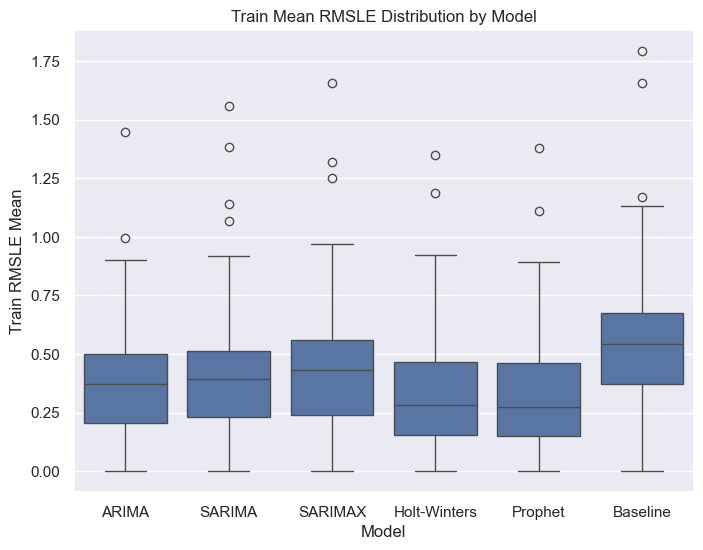

ARIMA Mean: 0.3821
SARIMA Mean: 0.4213
SARIMAX Mean: 0.4597
Holt-Winters Mean: 0.3264
Prophet Mean: 0.3204
Baseline Mean: 0.5462


In [28]:
# Train set mean

plt.rcParams['figure.figsize'] = (8, 6)

sns.boxplot(
    df_metrics,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

arima_train_mean = df_full_metrics_arima['train_rmsle_mean'].mean()
sarima_train_mean = df_full_metrics_sarima['train_rmsle_mean'].mean()
sarimax_train_mean = df_full_metrics_sarimax['train_rmsle_mean'].mean()
holt_winters_train_mean = df_full_metrics_holt_winters['train_rmsle_mean'].mean()
prophet_train_mean = df_full_metrics_prophet['train_rmsle_mean'].mean()
baseline_train_mean = df_full_metrics_baseline['train_rmsle_mean'].mean()

print(f"ARIMA Mean: {arima_train_mean:.4f}")
print(f"SARIMA Mean: {sarima_train_mean:.4f}")
print(f"SARIMAX Mean: {sarimax_train_mean:.4f}")
print(f"Holt-Winters Mean: {holt_winters_train_mean:.4f}")
print(f"Prophet Mean: {prophet_train_mean:.4f}")
print(f"Baseline Mean: {baseline_train_mean:.4f}")

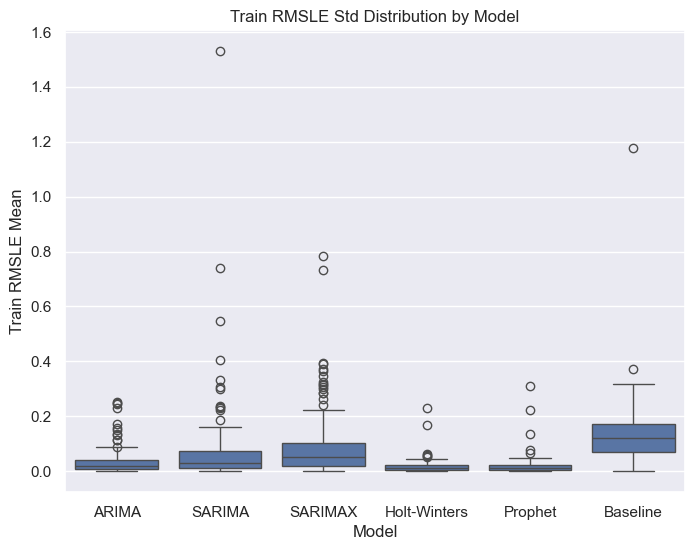

ARIMA std mean: 0.0410
SARIMA std mean: 0.0913
SARIMAX std mean: 0.1100
Holt-Winters std mean: 0.0192
Prophet std mean: 0.0220
Baseline std mean: 0.1401


In [29]:
# Train set std

sns.boxplot(
    df_metrics,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()


arima_train_std = df_full_metrics_arima['train_rmsle_std'].mean()
sarima_train_std = df_full_metrics_sarima['train_rmsle_std'].mean()
sarimax_train_std = df_full_metrics_sarimax['train_rmsle_std'].mean()
holt_winters_train_std = df_full_metrics_holt_winters['train_rmsle_std'].mean()
prophet_train_std = df_full_metrics_prophet['train_rmsle_std'].mean()
baseline_train_std = df_full_metrics_baseline['train_rmsle_std'].mean()

print(f"ARIMA std mean: {arima_train_std:.4f}")
print(f"SARIMA std mean: {sarima_train_std:.4f}")
print(f"SARIMAX std mean: {sarimax_train_std:.4f}")
print(f"Holt-Winters std mean: {holt_winters_train_std:.4f}")
print(f"Prophet std mean: {prophet_train_std:.4f}")
print(f"Baseline std mean: {baseline_train_std:.4f}")

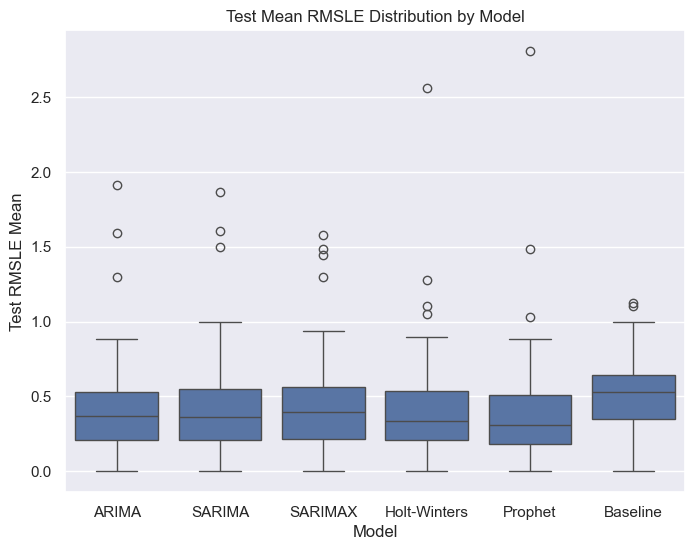

ARIMA Mean: 0.4062
SARIMA Mean: 0.4206
SARIMAX Mean: 0.4280
Holt-Winters Mean: 0.4006
Prophet Mean: 0.3938
Baseline Mean: 0.5124


In [30]:
sns.boxplot(
    df_metrics,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

arima_test_mean = df_full_metrics_arima['test_rmsle_mean'].mean()
sarima_test_mean = df_full_metrics_sarima['test_rmsle_mean'].mean()
sarimax_test_mean = df_full_metrics_sarimax['test_rmsle_mean'].mean()
holt_winters_test_mean = df_full_metrics_holt_winters['test_rmsle_mean'].mean()
prophet_test_mean = df_full_metrics_prophet['test_rmsle_mean'].mean()
baseline_test_mean = df_full_metrics_baseline['test_rmsle_mean'].mean()

print(f"ARIMA Mean: {arima_test_mean:.4f}")
print(f"SARIMA Mean: {sarima_test_mean:.4f}")
print(f"SARIMAX Mean: {sarimax_test_mean:.4f}")
print(f"Holt-Winters Mean: {holt_winters_test_mean:.4f}")
print(f"Prophet Mean: {prophet_test_mean:.4f}")
print(f"Baseline Mean: {baseline_test_mean:.4f}")

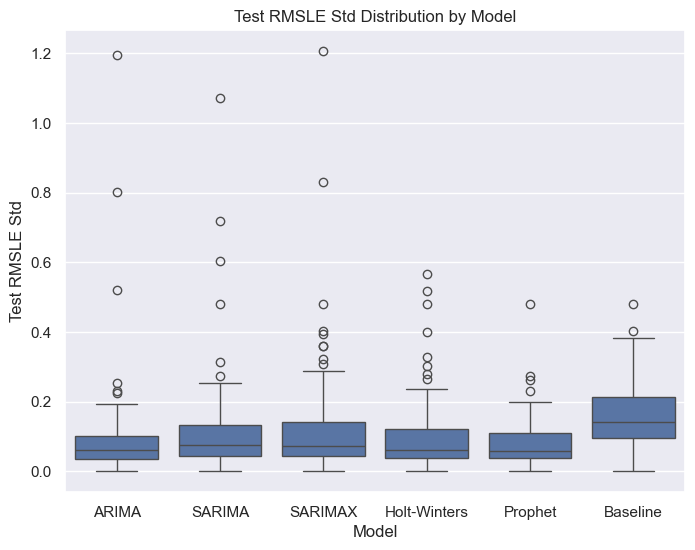

ARIMA std: 0.0991
SARIMA std: 0.1173
SARIMAX std: 0.1258
Holt-Winters std: 0.1013
Prophet std: 0.0826


In [31]:
# Test set std
sns.boxplot(
    df_metrics,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Test RMSLE Std Distribution by Model')

plt.show()

arima_test_std = df_full_metrics_arima['test_rmsle_std'].mean()
sarima_test_std = df_full_metrics_sarima['test_rmsle_std'].mean()
sarimax_test_std = df_full_metrics_sarimax['test_rmsle_std'].mean()
holt_winters_test_std = df_full_metrics_holt_winters['test_rmsle_std'].mean()
prophet_test_std = df_full_metrics_prophet['test_rmsle_std'].mean()

print(f"ARIMA std: {arima_test_std:.4f}")
print(f"SARIMA std: {sarima_test_std:.4f}")
print(f"SARIMAX std: {sarimax_test_std:.4f}")
print(f"Holt-Winters std: {holt_winters_test_std:.4f}")
print(f"Prophet std: {prophet_test_std:.4f}")

Holt-Winters got better metrics for the train set and SARIMA for the test set.

## 6. 2. By Demand Type

### 6. 2. 1. Smooth

In [32]:
df_full_metrics_arima_smooth = df_full_metrics_arima[df_full_metrics_arima['demand_type'] == 'smooth']
df_full_metrics_sarima_smooth = df_full_metrics_sarima[df_full_metrics_sarima['demand_type'] == 'smooth']
df_full_metrics_sarimax_smooth = df_full_metrics_sarimax[df_full_metrics_sarimax['demand_type'] == 'smooth']
df_full_metrics_holt_winters_smooth = df_full_metrics_holt_winters[df_full_metrics_holt_winters['demand_type'] == 'smooth']
df_full_metrics_prophet_smooth = df_full_metrics_prophet[df_full_metrics_prophet['demand_type'] == 'smooth']
df_full_metrics_baseline_smooth = df_full_metrics_baseline[df_full_metrics_baseline['demand_type'] == 'smooth']

df_metrics_smooth = df_metrics[df_metrics['demand_type'] == 'smooth']

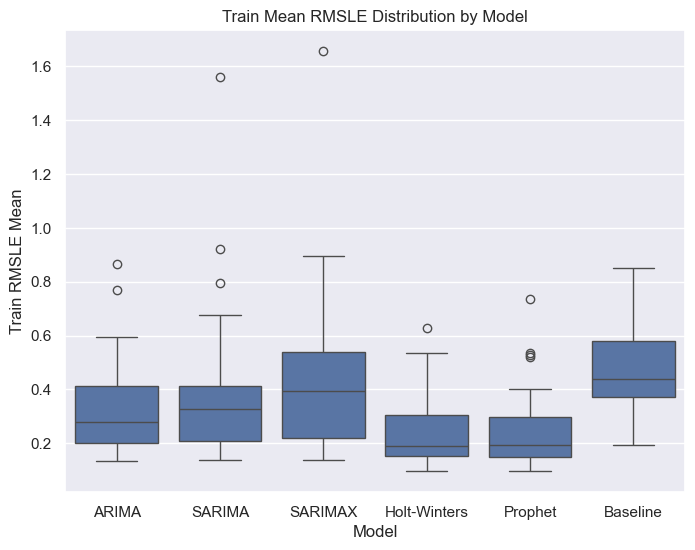

ARIMA Mean: 0.3208
SARIMA Mean: 0.3756
SARIMAX Mean: 0.4229
Holt-Winters Mean: 0.2442
Prophet Mean: 0.2414
Baseline Mean: 0.4775


In [33]:
# Train set mean

sns.boxplot(
    df_metrics_smooth,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

arima_train_mean = df_full_metrics_arima_smooth['train_rmsle_mean'].mean()
sarima_train_mean = df_full_metrics_sarima_smooth['train_rmsle_mean'].mean()
sarimax_train_mean = df_full_metrics_sarimax_smooth['train_rmsle_mean'].mean()
holt_winters_train_mean = df_full_metrics_holt_winters_smooth['train_rmsle_mean'].mean()
prophet_train_mean = df_full_metrics_prophet_smooth['train_rmsle_mean'].mean()
baseline_train_mean = df_full_metrics_baseline_smooth['train_rmsle_mean'].mean()

print(f"ARIMA Mean: {arima_train_mean:.4f}")
print(f"SARIMA Mean: {sarima_train_mean:.4f}")
print(f"SARIMAX Mean: {sarimax_train_mean:.4f}")
print(f"Holt-Winters Mean: {holt_winters_train_mean:.4f}")
print(f"Prophet Mean: {prophet_train_mean:.4f}")
print(f"Baseline Mean: {baseline_train_mean:.4f}")

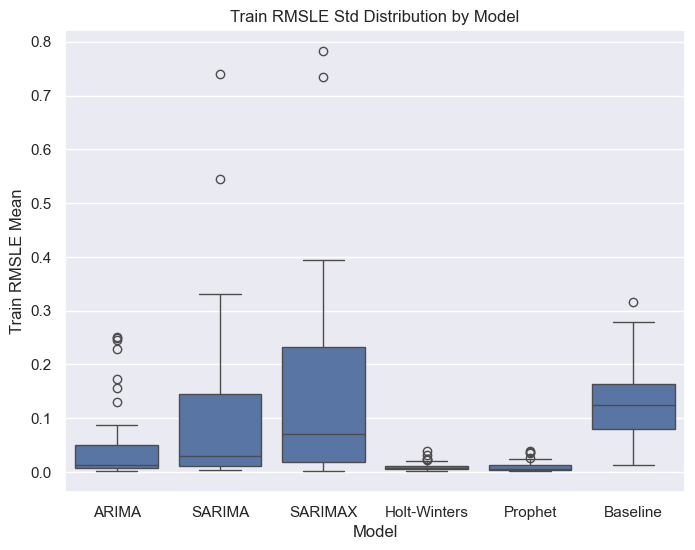

ARIMA std mean: 0.0480
SARIMA std mean: 0.0996
SARIMAX std mean: 0.1426
Holt-Winters std mean: 0.0098
Prophet std mean: 0.0104
Baseline std mean: 0.1315


In [34]:
# Train set std
sns.boxplot(
    df_metrics_smooth,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()


arima_train_std = df_full_metrics_arima_smooth['train_rmsle_std'].mean()
sarima_train_std = df_full_metrics_sarima_smooth['train_rmsle_std'].mean()
sarimax_train_std = df_full_metrics_sarimax_smooth['train_rmsle_std'].mean()
holt_winters_train_std = df_full_metrics_holt_winters_smooth['train_rmsle_std'].mean()
prophet_train_std = df_full_metrics_prophet_smooth['train_rmsle_std'].mean()
baseline_train_std = df_full_metrics_baseline_smooth['train_rmsle_std'].mean()

print(f"ARIMA std mean: {arima_train_std:.4f}")
print(f"SARIMA std mean: {sarima_train_std:.4f}")
print(f"SARIMAX std mean: {sarimax_train_std:.4f}")
print(f"Holt-Winters std mean: {holt_winters_train_std:.4f}")
print(f"Prophet std mean: {prophet_train_std:.4f}")
print(f"Baseline std mean: {baseline_train_std:.4f}")

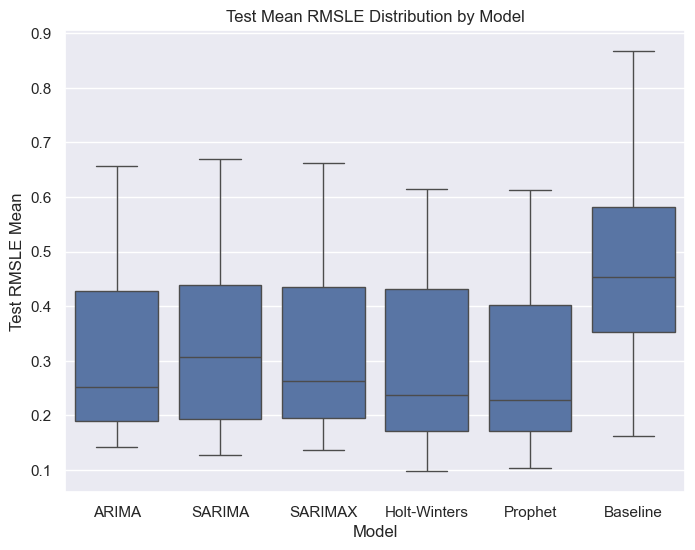

ARIMA Mean: 0.3126
SARIMA Mean: 0.3261
SARIMAX Mean: 0.3220
Holt-Winters Mean: 0.2944
Prophet Mean: 0.2838
Baseline Mean: 0.4658


In [35]:
sns.boxplot(
    df_metrics_smooth,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

arima_test_mean = df_full_metrics_arima_smooth['test_rmsle_mean'].mean()
sarima_test_mean = df_full_metrics_sarima_smooth['test_rmsle_mean'].mean()
sarimax_test_mean = df_full_metrics_sarimax_smooth['test_rmsle_mean'].mean()
holt_winters_test_mean = df_full_metrics_holt_winters_smooth['test_rmsle_mean'].mean()
prophet_test_mean = df_full_metrics_prophet_smooth['test_rmsle_mean'].mean()
baseline_test_mean = df_full_metrics_baseline_smooth['test_rmsle_mean'].mean()

print(f"ARIMA Mean: {arima_test_mean:.4f}")
print(f"SARIMA Mean: {sarima_test_mean:.4f}")
print(f"SARIMAX Mean: {sarimax_test_mean:.4f}")
print(f"Holt-Winters Mean: {holt_winters_test_mean:.4f}")
print(f"Prophet Mean: {prophet_test_mean:.4f}")
print(f"Baseline Mean: {baseline_test_mean:.4f}")

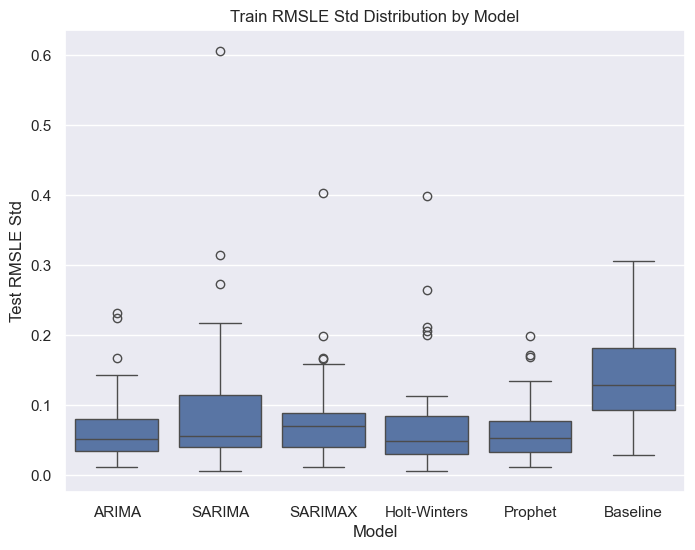

ARIMA std: 0.0655
SARIMA std: 0.0933
SARIMAX std: 0.0790
Holt-Winters std: 0.0725
Prophet std: 0.0624
Baseline std: 0.1420


In [36]:
# Test set std
sns.boxplot(
    df_metrics_smooth,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()

arima_test_std = df_full_metrics_arima_smooth['test_rmsle_std'].mean()
sarima_test_std = df_full_metrics_sarima_smooth['test_rmsle_std'].mean()
sarimax_test_std = df_full_metrics_sarimax_smooth['test_rmsle_std'].mean()
holt_winters_test_std = df_full_metrics_holt_winters_smooth['test_rmsle_std'].mean()
prophet_test_std = df_full_metrics_prophet_smooth['test_rmsle_std'].mean()
baseline_test_std = df_full_metrics_baseline_smooth['test_rmsle_std'].mean()

print(f"ARIMA std: {arima_test_std:.4f}")
print(f"SARIMA std: {sarima_test_std:.4f}")
print(f"SARIMAX std: {sarimax_test_std:.4f}")
print(f"Holt-Winters std: {holt_winters_test_std:.4f}")
print(f"Prophet std: {prophet_test_std:.4f}")
print(f"Baseline std: {baseline_test_std:.4f}")

Prophet got the best results for the train and test sets.

### 6. 2. 2. Intermittent

In [37]:
df_full_metrics_arima_intermittent = df_full_metrics_arima[df_full_metrics_arima['demand_type'] == 'intermittent']
df_full_metrics_sarima_intermittent = df_full_metrics_sarima[df_full_metrics_sarima['demand_type'] == 'intermittent']
df_full_metrics_sarimax_intermittent = df_full_metrics_sarimax[df_full_metrics_sarimax['demand_type'] == 'intermittent']
df_full_metrics_holt_winters_intermittent = df_full_metrics_holt_winters[df_full_metrics_holt_winters['demand_type'] == 'intermittent']
df_full_metrics_prophet_intermittent = df_full_metrics_prophet[df_full_metrics_prophet['demand_type'] == 'intermittent']
df_full_metrics_baseline_intermittent = df_full_metrics_baseline[df_full_metrics_baseline['demand_type'] == 'intermittent']

df_metrics_intermittent = df_metrics[df_metrics['demand_type'] == 'intermittent']

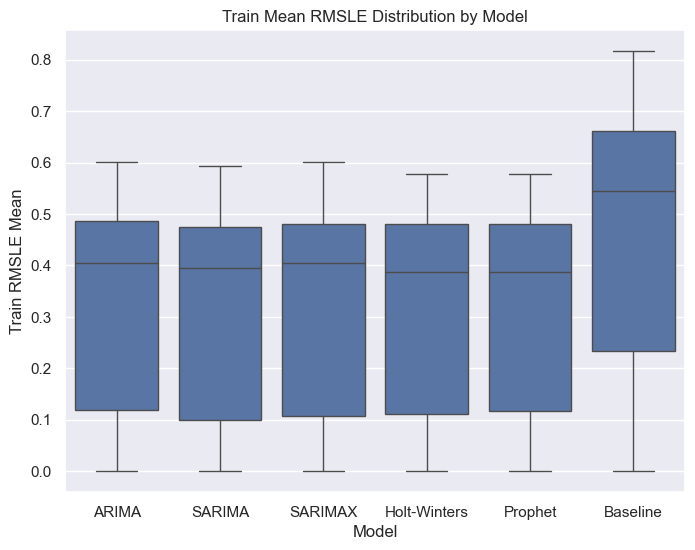

ARIMA Mean: 0.3172
SARIMA Mean: 0.3089
SARIMAX Mean: 0.3212
Holt-Winters Mean: 0.3111
Prophet Mean: 0.3113
Baseline Mean: 0.4555


In [38]:
# Train set mean

sns.boxplot(
    df_metrics_intermittent,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

arima_train_mean = df_full_metrics_arima_intermittent['train_rmsle_mean'].mean()
sarima_train_mean = df_full_metrics_sarima_intermittent['train_rmsle_mean'].mean()
sarimax_train_mean = df_full_metrics_sarimax_intermittent['train_rmsle_mean'].mean()
holt_winters_train_mean = df_full_metrics_holt_winters_intermittent['train_rmsle_mean'].mean()
prophet_train_mean = df_full_metrics_prophet_intermittent['train_rmsle_mean'].mean()
baseline_train_mean = df_full_metrics_baseline_intermittent['train_rmsle_mean'].mean()

print(f"ARIMA Mean: {arima_train_mean:.4f}")
print(f"SARIMA Mean: {sarima_train_mean:.4f}")
print(f"SARIMAX Mean: {sarimax_train_mean:.4f}")
print(f"Holt-Winters Mean: {holt_winters_train_mean:.4f}")
print(f"Prophet Mean: {prophet_train_mean:.4f}")
print(f"Baseline Mean: {baseline_train_mean:.4f}")

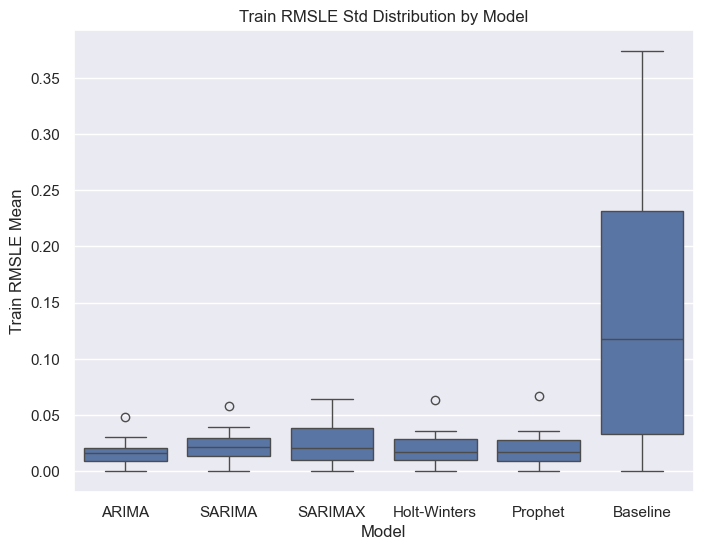

ARIMA std mean: 0.0164
SARIMA std mean: 0.0222
SARIMAX std mean: 0.0254
Holt-Winters std mean: 0.0196
Prophet std mean: 0.0195
Baseline std mean: 0.1356


In [39]:
# Train set std
sns.boxplot(
    df_metrics_intermittent,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()


arima_train_std = df_full_metrics_arima_intermittent['train_rmsle_std'].mean()
sarima_train_std = df_full_metrics_sarima_intermittent['train_rmsle_std'].mean()
sarimax_train_std = df_full_metrics_sarimax_intermittent['train_rmsle_std'].mean()
holt_winters_train_std = df_full_metrics_holt_winters_intermittent['train_rmsle_std'].mean()
prophet_train_std = df_full_metrics_prophet_intermittent['train_rmsle_std'].mean()
baseline_train_std = df_full_metrics_baseline_intermittent['train_rmsle_std'].mean()

print(f"ARIMA std mean: {arima_train_std:.4f}")
print(f"SARIMA std mean: {sarima_train_std:.4f}")
print(f"SARIMAX std mean: {sarimax_train_std:.4f}")
print(f"Holt-Winters std mean: {holt_winters_train_std:.4f}")
print(f"Prophet std mean: {prophet_train_std:.4f}")
print(f"Baseline std mean: {baseline_train_std:.4f}")

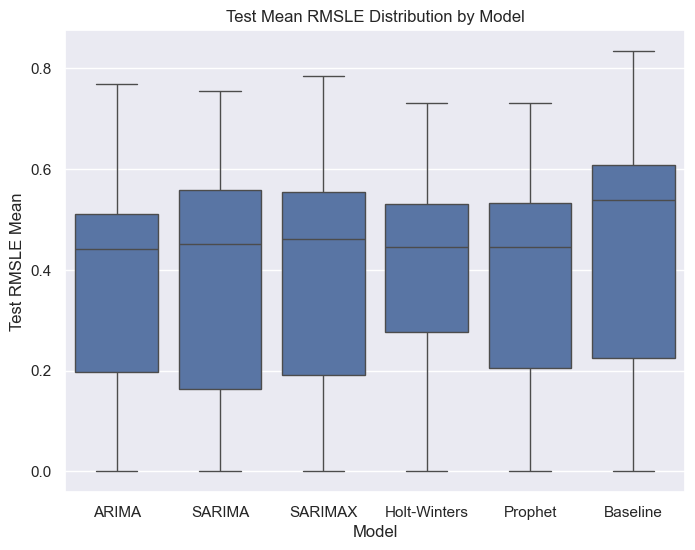

ARIMA Mean: 0.3576
SARIMA Mean: 0.3642
SARIMAX Mean: 0.3830
Holt-Winters Mean: 0.3740
Prophet Mean: 0.3602
Baseline Mean: 0.4264


In [40]:
sns.boxplot(
    df_metrics_intermittent,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

arima_test_mean = df_full_metrics_arima_intermittent['test_rmsle_mean'].mean()
sarima_test_mean = df_full_metrics_sarima_intermittent['test_rmsle_mean'].mean()
sarimax_test_mean = df_full_metrics_sarimax_intermittent['test_rmsle_mean'].mean()
holt_winters_test_mean = df_full_metrics_holt_winters_intermittent['test_rmsle_mean'].mean()
prophet_test_mean = df_full_metrics_prophet_intermittent['test_rmsle_mean'].mean()
baseline_test_mean = df_full_metrics_baseline_intermittent['test_rmsle_mean'].mean()

print(f"ARIMA Mean: {arima_test_mean:.4f}")
print(f"SARIMA Mean: {sarima_test_mean:.4f}")
print(f"SARIMAX Mean: {sarimax_test_mean:.4f}")
print(f"Holt-Winters Mean: {holt_winters_test_mean:.4f}")
print(f"Prophet Mean: {prophet_test_mean:.4f}")
print(f"Baseline Mean: {baseline_test_mean:.4f}")

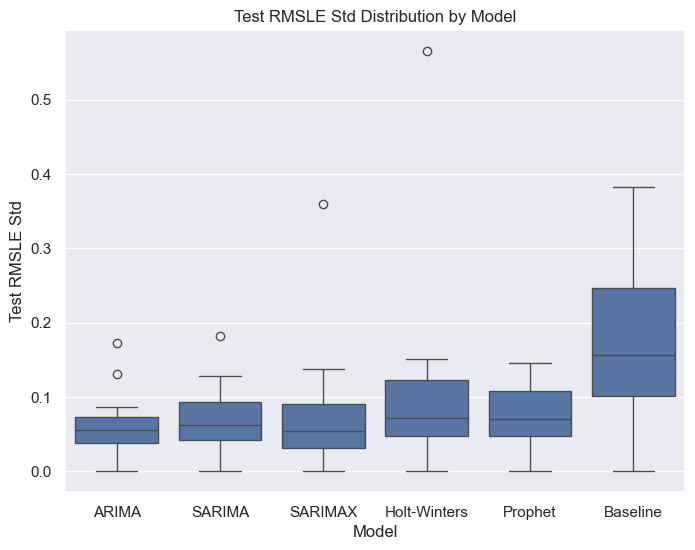

ARIMA std: 0.0602
SARIMA std: 0.0698
SARIMAX std: 0.0770
Holt-Winters std: 0.1066
Prophet std: 0.0720
Baseline std: 0.1682


In [41]:
# Test set std
sns.boxplot(
    df_metrics_intermittent,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Test RMSLE Std Distribution by Model')

plt.show()

arima_test_std = df_full_metrics_arima_intermittent['test_rmsle_std'].mean()
sarima_test_std = df_full_metrics_sarima_intermittent['test_rmsle_std'].mean()
sarimax_test_std = df_full_metrics_sarimax_intermittent['test_rmsle_std'].mean()
holt_winters_test_std = df_full_metrics_holt_winters_intermittent['test_rmsle_std'].mean()
prophet_test_std = df_full_metrics_prophet_intermittent['test_rmsle_std'].mean()
baseline_test_std = df_full_metrics_baseline_intermittent['test_rmsle_std'].mean()

print(f"ARIMA std: {arima_test_std:.4f}")
print(f"SARIMA std: {sarima_test_std:.4f}")
print(f"SARIMAX std: {sarimax_test_std:.4f}")
print(f"Holt-Winters std: {holt_winters_test_std:.4f}")
print(f"Prophet std: {prophet_test_std:.4f}")
print(f"Baseline std: {baseline_test_std:.4f}")

SARIMA got better results for the train set and ARIMA for the test set.

### 6. 2. 3. Erratic

In [42]:
df_full_metrics_arima_erratic = df_full_metrics_arima[df_full_metrics_arima['demand_type'] == 'erratic']
df_full_metrics_sarima_erratic = df_full_metrics_sarima[df_full_metrics_sarima['demand_type'] == 'erratic']
df_full_metrics_sarimax_erratic = df_full_metrics_sarimax[df_full_metrics_sarimax['demand_type'] == 'erratic']
df_full_metrics_holt_winters_erratic = df_full_metrics_holt_winters[df_full_metrics_holt_winters['demand_type'] == 'erratic']
df_full_metrics_prophet_erratic = df_full_metrics_prophet[df_full_metrics_prophet['demand_type'] == 'erratic']
df_full_metrics_baseline_erratic = df_full_metrics_baseline[df_full_metrics_baseline['demand_type'] == 'erratic']

df_metrics_erratic = df_metrics[df_metrics['demand_type'] == 'erratic']

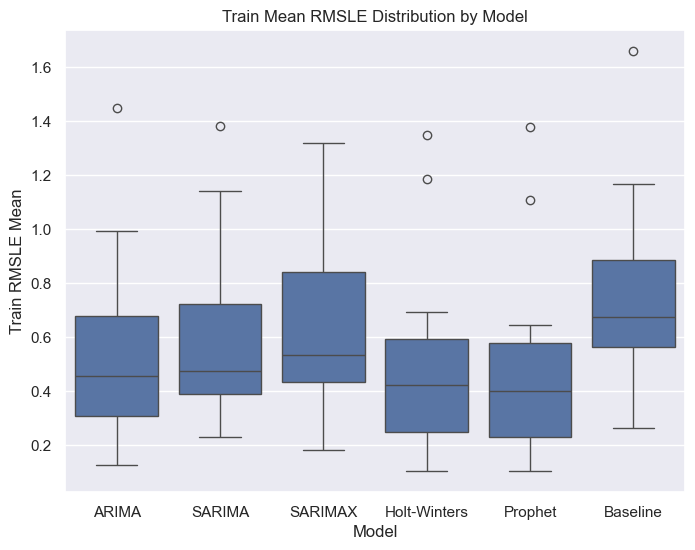

ARIMA Mean: 0.5294
SARIMA Mean: 0.5873
SARIMAX Mean: 0.6267
Holt-Winters Mean: 0.4782
Prophet Mean: 0.4628
Baseline Mean: 0.7220


In [43]:
# Train set mean

sns.boxplot(
    df_metrics_erratic,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

arima_train_mean = df_full_metrics_arima_erratic['train_rmsle_mean'].mean()
sarima_train_mean = df_full_metrics_sarima_erratic['train_rmsle_mean'].mean()
sarimax_train_mean = df_full_metrics_sarimax_erratic['train_rmsle_mean'].mean()
holt_winters_train_mean = df_full_metrics_holt_winters_erratic['train_rmsle_mean'].mean()
prophet_train_mean = df_full_metrics_prophet_erratic['train_rmsle_mean'].mean()
baseline_train_mean = df_full_metrics_baseline_erratic['train_rmsle_mean'].mean()

print(f"ARIMA Mean: {arima_train_mean:.4f}")
print(f"SARIMA Mean: {sarima_train_mean:.4f}")
print(f"SARIMAX Mean: {sarimax_train_mean:.4f}")
print(f"Holt-Winters Mean: {holt_winters_train_mean:.4f}")
print(f"Prophet Mean: {prophet_train_mean:.4f}")
print(f"Baseline Mean: {baseline_train_mean:.4f}")

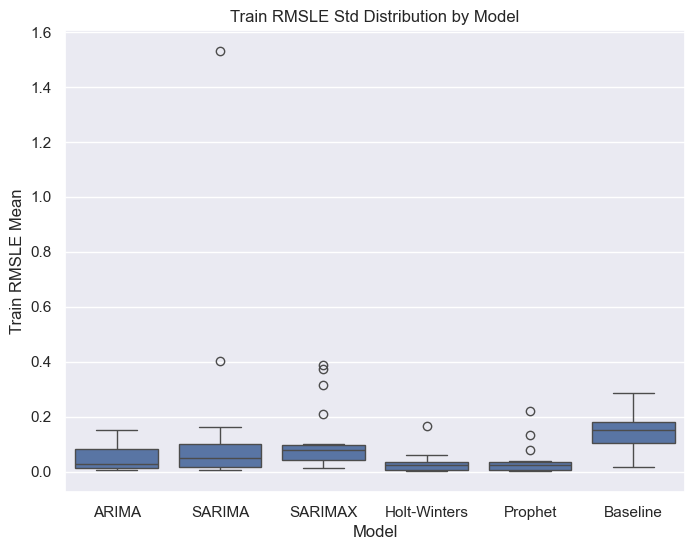

ARIMA std mean: 0.0479
SARIMA std mean: 0.1502
SARIMAX std mean: 0.1141
Holt-Winters std mean: 0.0306
Prophet std mean: 0.0385
Baseline std mean: 0.1417


In [44]:
# Train set std
sns.boxplot(
    df_metrics_erratic,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()


arima_train_std = df_full_metrics_arima_erratic['train_rmsle_std'].mean()
sarima_train_std = df_full_metrics_sarima_erratic['train_rmsle_std'].mean()
sarimax_train_std = df_full_metrics_sarimax_erratic['train_rmsle_std'].mean()
holt_winters_train_std = df_full_metrics_holt_winters_erratic['train_rmsle_std'].mean()
prophet_train_std = df_full_metrics_prophet_erratic['train_rmsle_std'].mean()
baseline_train_std = df_full_metrics_baseline_erratic['train_rmsle_std'].mean()

print(f"ARIMA std mean: {arima_train_std:.4f}")
print(f"SARIMA std mean: {sarima_train_std:.4f}")
print(f"SARIMAX std mean: {sarimax_train_std:.4f}")
print(f"Holt-Winters std mean: {holt_winters_train_std:.4f}")
print(f"Prophet std mean: {prophet_train_std:.4f}")
print(f"Baseline std mean: {baseline_train_std:.4f}")

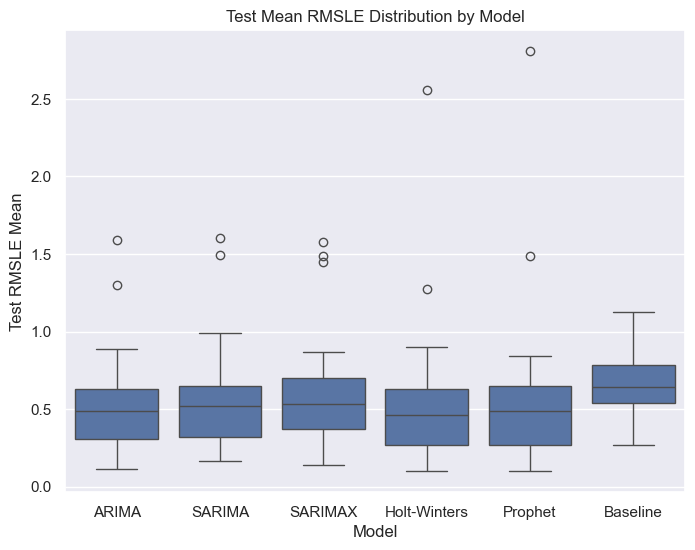

ARIMA Mean: 0.5520
SARIMA Mean: 0.5835
SARIMAX Mean: 0.6262
Holt-Winters Mean: 0.5894
Prophet Mean: 0.6132
Baseline Mean: 0.6454


In [45]:
sns.boxplot(
    df_metrics_erratic,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

arima_test_mean = df_full_metrics_arima_erratic['test_rmsle_mean'].mean()
sarima_test_mean = df_full_metrics_sarima_erratic['test_rmsle_mean'].mean()
sarimax_test_mean = df_full_metrics_sarimax_erratic['test_rmsle_mean'].mean()
holt_winters_test_mean = df_full_metrics_holt_winters_erratic['test_rmsle_mean'].mean()
prophet_test_mean = df_full_metrics_prophet_erratic['test_rmsle_mean'].mean()
baseline_test_mean = df_full_metrics_baseline_erratic['test_rmsle_mean'].mean()

print(f"ARIMA Mean: {arima_test_mean:.4f}")
print(f"SARIMA Mean: {sarima_test_mean:.4f}")
print(f"SARIMAX Mean: {sarimax_test_mean:.4f}")
print(f"Holt-Winters Mean: {holt_winters_test_mean:.4f}")
print(f"Prophet Mean: {prophet_test_mean:.4f}")
print(f"Baseline Mean: {baseline_test_mean:.4f}")

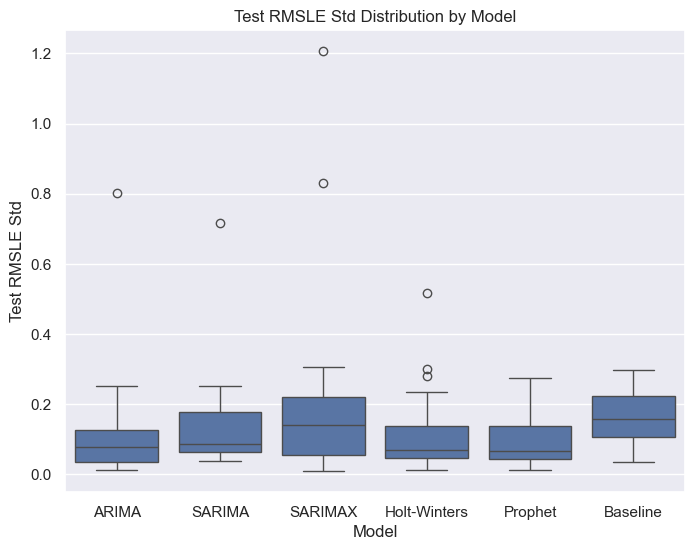

ARIMA std: 0.1248
SARIMA std: 0.1452
SARIMAX std: 0.2200
Holt-Winters std: 0.1226
Prophet std: 0.0976
Baseline std: 0.1626


In [46]:
# Test set std
sns.boxplot(
    df_metrics_erratic,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Test RMSLE Std Distribution by Model')

plt.show()

arima_test_std = df_full_metrics_arima_erratic['test_rmsle_std'].mean()
sarima_test_std = df_full_metrics_sarima_erratic['test_rmsle_std'].mean()
sarimax_test_std = df_full_metrics_sarimax_erratic['test_rmsle_std'].mean()
holt_winters_test_std = df_full_metrics_holt_winters_erratic['test_rmsle_std'].mean()
prophet_test_std = df_full_metrics_prophet_erratic['test_rmsle_std'].mean()
baseline_test_std = df_full_metrics_baseline_erratic['test_rmsle_std'].mean()

print(f"ARIMA std: {arima_test_std:.4f}")
print(f"SARIMA std: {sarima_test_std:.4f}")
print(f"SARIMAX std: {sarimax_test_std:.4f}")
print(f"Holt-Winters std: {holt_winters_test_std:.4f}")
print(f"Prophet std: {prophet_test_std:.4f}")
print(f"Baseline std: {baseline_test_std:.4f}")

Prophet did better for train set and ARIMA for test set.

### 6. 2. 4. Lumpy

In [47]:
df_full_metrics_arima_lumpy = df_full_metrics_arima[df_full_metrics_arima['demand_type'] == 'lumpy']
df_full_metrics_sarima_lumpy = df_full_metrics_sarima[df_full_metrics_sarima['demand_type'] == 'lumpy']
df_full_metrics_sarimax_lumpy = df_full_metrics_sarimax[df_full_metrics_sarimax['demand_type'] == 'lumpy']
df_full_metrics_holt_winters_lumpy = df_full_metrics_holt_winters[df_full_metrics_holt_winters['demand_type'] == 'lumpy']
df_full_metrics_prophet_lumpy = df_full_metrics_prophet[df_full_metrics_prophet['demand_type'] == 'lumpy']
df_full_metrics_baseline_lumpy = df_full_metrics_baseline[df_full_metrics_baseline['demand_type'] == 'lumpy']

df_metrics_lumpy = df_metrics[df_metrics['demand_type'] == 'lumpy']

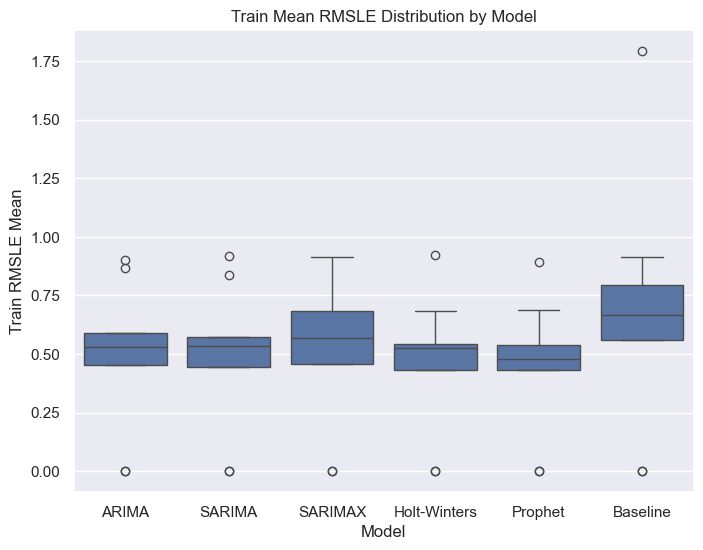

ARIMA Mean: 0.4917
SARIMA Mean: 0.4843
SARIMAX Mean: 0.5153
Holt-Winters Mean: 0.4596
Prophet Mean: 0.4459
Baseline Mean: 0.6751


In [48]:
# Train set mean

sns.boxplot(
    df_metrics_lumpy,
    x='Model',
    y='train_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train Mean RMSLE Distribution by Model')

plt.show()

arima_train_mean = df_full_metrics_arima_lumpy['train_rmsle_mean'].mean()
sarima_train_mean = df_full_metrics_sarima_lumpy['train_rmsle_mean'].mean()
sarimax_train_mean = df_full_metrics_sarimax_lumpy['train_rmsle_mean'].mean()
holt_winters_train_mean = df_full_metrics_holt_winters_lumpy['train_rmsle_mean'].mean()
prophet_train_mean = df_full_metrics_prophet_lumpy['train_rmsle_mean'].mean()
baseline_train_mean = df_full_metrics_baseline_lumpy['train_rmsle_mean'].mean()

print(f"ARIMA Mean: {arima_train_mean:.4f}")
print(f"SARIMA Mean: {sarima_train_mean:.4f}")
print(f"SARIMAX Mean: {sarimax_train_mean:.4f}")
print(f"Holt-Winters Mean: {holt_winters_train_mean:.4f}")
print(f"Prophet Mean: {prophet_train_mean:.4f}")
print(f"Baseline Mean: {baseline_train_mean:.4f}")

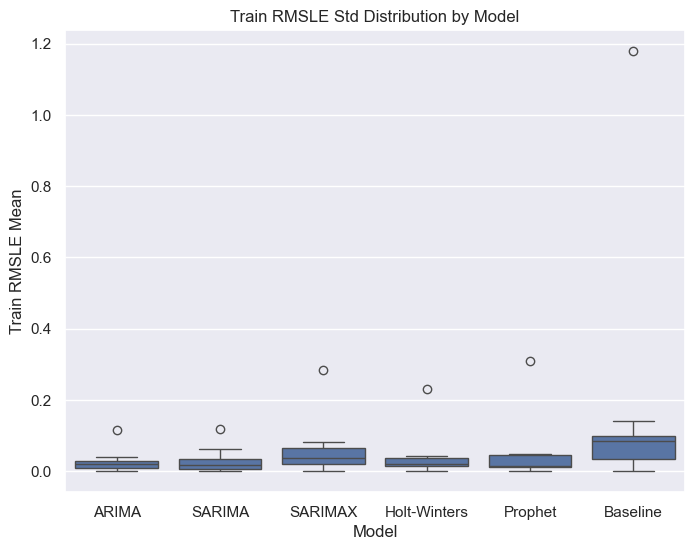

ARIMA std mean: 0.0276
SARIMA std mean: 0.0314
SARIMAX std mean: 0.0631
Holt-Winters std mean: 0.0440
Prophet std mean: 0.0519
Baseline std mean: 0.1889


In [49]:
# Train set std
sns.boxplot(
    df_metrics_lumpy,
    x='Model',
    y='train_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Train RMSLE Mean')
plt.title('Train RMSLE Std Distribution by Model')

plt.show()


arima_train_std = df_full_metrics_arima_lumpy['train_rmsle_std'].mean()
sarima_train_std = df_full_metrics_sarima_lumpy['train_rmsle_std'].mean()
sarimax_train_std = df_full_metrics_sarimax_lumpy['train_rmsle_std'].mean()
holt_winters_train_std = df_full_metrics_holt_winters_lumpy['train_rmsle_std'].mean()
prophet_train_std = df_full_metrics_prophet_lumpy['train_rmsle_std'].mean()
baseline_train_std = df_full_metrics_baseline_lumpy['train_rmsle_std'].mean()

print(f"ARIMA std mean: {arima_train_std:.4f}")
print(f"SARIMA std mean: {sarima_train_std:.4f}")
print(f"SARIMAX std mean: {sarimax_train_std:.4f}")
print(f"Holt-Winters std mean: {holt_winters_train_std:.4f}")
print(f"Prophet std mean: {prophet_train_std:.4f}")
print(f"Baseline std mean: {baseline_train_std:.4f}")

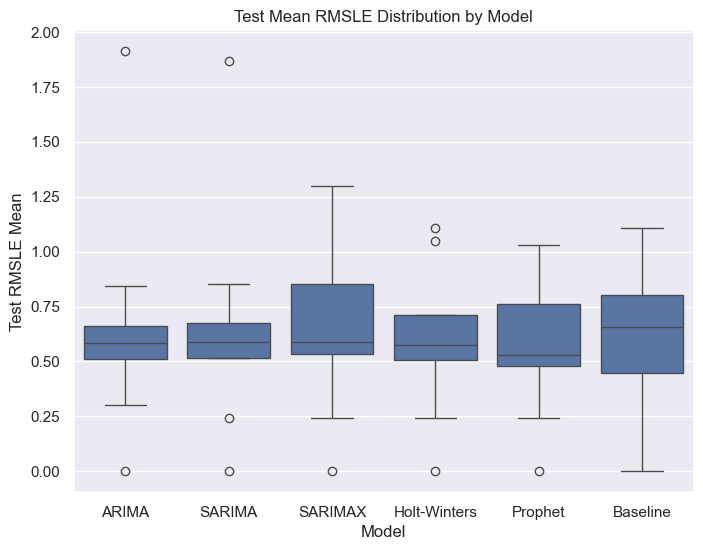

ARIMA Mean: 0.6622
SARIMA Mean: 0.6580
SARIMAX Mean: 0.6334
Holt-Winters Mean: 0.5976
Prophet Mean: 0.5571
Baseline Mean: 0.6087


In [50]:
sns.boxplot(
    df_metrics_lumpy,
    x='Model',
    y='test_rmsle_mean'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Mean')
plt.title('Test Mean RMSLE Distribution by Model')

plt.show()

arima_test_mean = df_full_metrics_arima_lumpy['test_rmsle_mean'].mean()
sarima_test_mean = df_full_metrics_sarima_lumpy['test_rmsle_mean'].mean()
sarimax_test_mean = df_full_metrics_sarimax_lumpy['test_rmsle_mean'].mean()
holt_winters_test_mean = df_full_metrics_holt_winters_lumpy['test_rmsle_mean'].mean()
prophet_test_mean = df_full_metrics_prophet_lumpy['test_rmsle_mean'].mean()
baseline_test_mean = df_full_metrics_baseline_lumpy['test_rmsle_mean'].mean()

print(f"ARIMA Mean: {arima_test_mean:.4f}")
print(f"SARIMA Mean: {sarima_test_mean:.4f}")
print(f"SARIMAX Mean: {sarimax_test_mean:.4f}")
print(f"Holt-Winters Mean: {holt_winters_test_mean:.4f}")
print(f"Prophet Mean: {prophet_test_mean:.4f}")
print(f"Baseline Mean: {baseline_test_mean:.4f}")

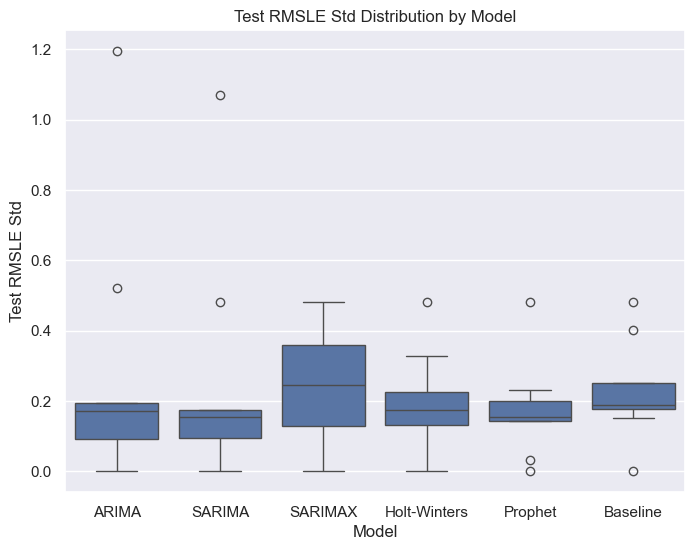

ARIMA std: 0.2808
SARIMA std: 0.2569
SARIMAX std: 0.2473
Holt-Winters std: 0.1984
Prophet std: 0.1727
Baseline std: 0.2278


In [51]:
# Test set std
sns.boxplot(
    df_metrics_lumpy,
    x='Model',
    y='test_rmsle_std'
)

plt.xlabel('Model')
plt.ylabel('Test RMSLE Std')
plt.title('Test RMSLE Std Distribution by Model')

plt.show()

arima_test_std = df_full_metrics_arima_lumpy['test_rmsle_std'].mean()
sarima_test_std = df_full_metrics_sarima_lumpy['test_rmsle_std'].mean()
sarimax_test_std = df_full_metrics_sarimax_lumpy['test_rmsle_std'].mean()
holt_winters_test_std = df_full_metrics_holt_winters_lumpy['test_rmsle_std'].mean()
prophet_test_std = df_full_metrics_prophet_lumpy['test_rmsle_std'].mean()
baseline_test_std = df_full_metrics_baseline_lumpy['test_rmsle_std'].mean()

print(f"ARIMA std: {arima_test_std:.4f}")
print(f"SARIMA std: {sarima_test_std:.4f}")
print(f"SARIMAX std: {sarimax_test_std:.4f}")
print(f"Holt-Winters std: {holt_winters_test_std:.4f}")
print(f"Prophet std: {prophet_test_std:.4f}")
print(f"Baseline std: {baseline_test_std:.4f}")

Prophet did better for training and test sets.

# 7. Final Conclusions

Prophet got the best results for training and test sets, except for intermittent series. 